# Financial Forecasting Frontier
## Leakage-Safe Banking Term Deposit Prediction

**Project type:** End Course Summative Assignment  
**Contribution:** Individual  
**Student:** Prashant Verma  
**Notebook scope:** Exploratory data analysis, statistical testing and machine learning  
**Dataset:** `bank.csv` (4,521 banking campaign records)

## Project Summary

This notebook is the Colab part of my Financial Forecasting Frontier project. It uses `bank.csv`, which has **4,521 campaign records and 17 columns**, to study whether a customer is likely to subscribe to a term deposit. Only **521 customers** subscribed, so the positive class is about **11.5%** of the data and accuracy alone would not be a useful way to judge the model.

The prediction is made **before the current campaign call begins**. I therefore excluded `duration` from every model because call duration is only known after the conversation. Keeping it would make the score look better but would not support real pre-call customer prioritization. I used it only in a marked EDA chart to show why it is a leakage risk.

I started with data-quality checks, training-only EDA, visual analysis and three hypothesis tests with effect sizes. The initial split keeps 60% for target-aware analysis, 20% as additional development data and 20% as a held-out evaluation set. After EDA, the first two parts are combined into an 80% development set. All learned preprocessing and feature engineering stay inside fold-fitted pipelines.

The modeling section compares a dummy baseline, Logistic Regression, Random Forest, Histogram Gradient Boosting and CatBoost using repeated stratified cross-validation with PR-AUC as the main score. Random Forest is the strongest single model, while CatBoost is a close second. I then use fold-safe probabilities from Logistic Regression, Random Forest and CatBoost to test a calibrated blend. The calibrated blend is selected because it keeps similar ranking performance while improving the OOF Brier score from the **0.1020** prevalence baseline to **0.0884**.

On the held-out split, the final calibrated blend reaches PR-AUC **0.3874**, ROC-AUC **0.7576**, precision **0.3873**, recall **0.5288** and F1 **0.4472**. Its Brier score is **0.0874**, compared with **0.1017** for the held-out prevalence baseline. The highest-scored 10% of customers gives lift **3.73** and captures **37.5%** of the subscribers.

The result is useful as a contact-priority score, not as a guarantee that someone will subscribe. Performance depends strongly on previous campaign history, and the subgroup review shows weak recall when contact information is unknown. The complete project also includes Hadoop, Hive, Spark EDA, Spark ML, Structured Streaming and data-parallelism work in the linked GitHub repository.


## GitHub Repository Link

[https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML)

The repository contains the distributed parts of the project. This notebook complements them and does not replace them.

| Project part | Repository evidence |
|---|---|
| Hadoop MapReduce and HDFS workflow | [`hadoop/`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML/tree/main/hadoop) |
| Hive analysis | [`hive/`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML/tree/main/hive) |
| Spark EDA and machine learning | [`spark/eda/`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML/tree/main/spark/eda), [`spark/ml/`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML/tree/main/spark/ml) |
| Spark Structured Streaming | [`spark/streaming/`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML/tree/main/spark/streaming) |
| Data parallelism | [`spark/parallelism/`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML/tree/main/spark/parallelism) |
| Setup and full project explanation | [`README.md`](https://github.com/I-AM-PRASHANT-VERMA/almabetter-Financial-Forecasting-Frontier-Distributed-ML) |

## Problem Statement

Build a leakage-safe model that ranks bank customers by their likelihood of subscribing to a term deposit, using only information available before the current campaign call begins. The final output should support contact prioritization and provide reasonably calibrated probabilities without treating the prediction as a guaranteed customer decision.

### Questions explored

1. Which customer, account and campaign characteristics are associated with subscription?
2. Can learned models rank subscribers better than a prior-probability baseline?
3. Does a calibrated multi-model blend improve probability quality without losing useful PR-AUC?
4. What precision-recall trade-off is produced by a threshold selected from out-of-fold development predictions?
5. How dependent is performance on previous campaign history, contact channel and age?
6. Which customer groups still show weak recall or over-targeting?

### Success criteria

- Beat the dummy baseline on repeated cross-validation PR-AUC.
- Keep held-out labels outside feature design, model tuning, blending, calibration and threshold selection.
- Improve probability calibration compared with the constant-prevalence Brier baseline.
- Report precision, recall, F1, balanced accuracy, uncertainty and contact-budget lift.
- Explain robustness and subgroup weaknesses instead of reporting only one overall score.
- Save and reload the complete base-model, calibration and threshold artifact.


## 1. Know Your Data

In [1]:
# Code Cell 01: Import core libraries and set notebook defaults.

# Core libraries used by the analysis and model pipeline.
import importlib.util
import platform
import subprocess
import sys
import warnings
from pathlib import Path

# CatBoost is installed only when the current Colab runtime does not already have it.
if importlib.util.find_spec("catboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost"])

import catboost
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from catboost import CatBoostClassifier
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
print({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "catboost": catboost.__version__,
})


{'Python': '3.12.13', 'pandas': '2.2.2', 'scikit-learn': '1.6.1', 'catboost': '1.2.10'}


In [2]:
# Code Cell 02: Mount Google Drive for project files.

# The notebook reads its dataset and saves its model inside this project folder.
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Code Cell 03: Load the banking dataset from the project folder.

# Only the submitted bank.csv file in Google Drive is used.
PROJECT_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/# specialization projects/2nd project Financial Forecasting Frontier Distributed ML"
)
DATA_PATH = PROJECT_PATH / "bank.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "bank.csv was not found in the Financial Forecasting Frontier project folder."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {DATA_PATH.name}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Loaded dataset: bank.csv
Shape: 4,521 rows x 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


The submitted `bank.csv` file loaded successfully with **4,521 rows and 17 columns**. The preview confirms that the target is `y` and that customer, account and campaign fields are present.

### Dataset Rows and Columns

In [4]:
# Code Cell 04: Review column types, missing values, and unique counts.

# Schema checks confirm which columns need numeric or categorical handling.
# Keep data type, missing count, and cardinality in one review table.
schema_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
})
# Show every column so later preprocessing choices can be checked against the raw schema.
display(schema_summary)

,dtype,missing,unique
age,int64,0,67
job,object,0,12
marital,object,0,3
education,object,0,4
default,object,0,2
balance,int64,0,2353
housing,object,0,2
loan,object,0,2
contact,object,0,3
day,int64,0,31


The schema contains seven numeric fields and ten categorical fields including the target. No blank values are reported, but categorical placeholder values still need a separate check.

### Variable Description

| Variable | Meaning | Model role |
|---|---|---|
| `age` | Customer age | Numeric predictor |
| `job`, `marital`, `education` | Customer profile | Categorical predictors |
| `default`, `housing`, `loan` | Credit and loan indicators | Categorical predictors |
| `balance` | Average yearly account balance | Numeric predictor |
| `contact` | Contact communication type | Categorical predictor |
| `day`, `month` | Last contact calendar fields | Predictors; no full date is available |
| `duration` | Last call duration in seconds | **EDA only; excluded because it is post-call** |
| `campaign` | Contacts in the current campaign | Numeric predictor |
| `pdays` | Days since previous contact; `-1` means not previously contacted | Numeric predictor plus derived flag |
| `previous` | Number of contacts before this campaign | Numeric predictor |
| `poutcome` | Previous campaign outcome | Categorical predictor |
| `y` | Whether the customer subscribed | Binary target |

`unknown` values are retained as explicit categories. They represent unavailable information in the source system, not blank cells that can be safely guessed.

## 2. Understanding the Variables

In [5]:
# Code Cell 05: Check duplicates, placeholder categories, and numeric ranges.

# Data-quality checks are completed before target-aware analysis.
# Treat the word 'unknown' as a recorded category, not as a blank value.
unknown_summary = pd.DataFrame({
    "unknown_count": {
        column: int(df[column].eq("unknown").sum())
        for column in df.select_dtypes(include="object").columns
        if df[column].eq("unknown").any()
    }
})
# Percentages make the large poutcome and contact gaps easier to judge.
unknown_summary["unknown_percent"] = (
    unknown_summary["unknown_count"] / len(df) * 100
).round(2)

# Keep duplicate, missing, and class counts together for a quick data-quality check.
quality_summary = pd.Series({
    "rows": len(df),
    "columns": len(df.columns),
    "exact_duplicates": int(df.duplicated().sum()),
    "missing_cells": int(df.isna().sum().sum()),
    "non_subscribers": int(df["y"].eq("no").sum()),
    "subscribers": int(df["y"].eq("yes").sum()),
}, name="value").to_frame()

display(quality_summary)
display(unknown_summary.sort_values("unknown_count", ascending=False))
# Numeric ranges are reviewed here, but no values are capped or removed at this stage.
display(df.describe().T)

,value
rows,4521
columns,17
exact_duplicates,0
missing_cells,0
non_subscribers,4000
subscribers,521


,unknown_count,unknown_percent
poutcome,3705,81.95
contact,1324,29.29
education,187,4.14
job,38,0.84


,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


There are **0 exact duplicates** and **0 blank cells**. The important source placeholders are `job` (38 unknown), `education` (187), `contact` (1,324) and `poutcome` (3,705). They are retained as categories because replacing them with guessed values would add unsupported information.

The file has no exact duplicate rows and no blank cells. However, `unknown` appears in some categorical columns and is treated as a valid source-system state. The target is imbalanced, so a high accuracy score by itself could hide poor subscription detection.

## 3. Data Wrangling

In [6]:
# Code Cell 06: Create stratified training, validation, and test splits.

# The split is completed before EDA or preprocessing learns from target patterns.
# Convert yes/no only for stratification while keeping the original labels in each split.
target = df["y"].map({"no": 0, "yes": 1})
if target.isna().any():
    raise ValueError("Unexpected target label found in y.")

# Set aside 40% before any target-based EDA or model fitting starts.
train_df, holdout_df = train_test_split(
    df,
    test_size=0.40,
    stratify=target,
    random_state=RANDOM_STATE,
)
# Divide the holdout equally so model selection and final testing stay separate.
validation_df, test_df = train_test_split(
    holdout_df,
    test_size=0.50,
    stratify=holdout_df["y"],
    random_state=RANDOM_STATE,
)

# Index sets give direct proof that the three data partitions do not share rows.
split_indices = {
    "train": set(train_df.index),
    "validation": set(validation_df.index),
    "test": set(test_df.index),
}
split_pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]
# Stop the notebook immediately if any pair of splits overlaps.
for left, right in split_pairs:
    if split_indices[left] & split_indices[right]:
        raise ValueError(f"Row overlap found between {left} and {right}.")

# The union check also confirms that no source row disappeared during splitting.
covered_indices = set().union(*split_indices.values())
if covered_indices != set(df.index):
    raise ValueError("The split does not cover every source row exactly once.")

# Similar positive rates verify that stratification worked as intended.
split_summary = pd.DataFrame({
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "positive_rate": [
        train_df["y"].eq("yes").mean(),
        validation_df["y"].eq("yes").mean(),
        test_df["y"].eq("yes").mean(),
    ],
}, index=["train", "validation", "test"])
display(split_summary.round({"positive_rate": 4}))
print("Split integrity check: PASS - no row overlap and full row coverage.")

,rows,positive_rate
train,2712,0.1154
validation,904,0.1150
test,905,0.1149


Split integrity check: PASS - no row overlap and full row coverage.


The initial split contains separate training, validation and test partitions with similar positive rates. Target-aware EDA uses only the training partition. After EDA is complete, the first two partitions are combined into an 80% development set for repeated cross-validation, while the final 20% test set remains sealed.


### Wrangling decisions

- The first split is 60% training, 20% validation and 20% test with target stratification.
- Target-aware EDA and hypothesis tests use only the 60% training partition.
- Model tuning later combines training and validation into an 80% development set.
- Repeated stratified cross-validation makes model selection less dependent on one lucky validation split.
- The 20% test partition is used only after the model and operating threshold are frozen.
- Exact source indices verify zero overlap and complete row coverage.


## 4. Data Visualization, Storytelling and Experimenting with Charts

All target-aware charts below use only the training split.

In [7]:
# Code Cell 07: Prepare training-only columns for EDA.

# Readable labels and groups are created only for training-period analysis.
# Use a separate training-only frame so chart preparation cannot change modeling data.
eda = train_df.copy()
# Readable labels make plots easier to explain than numeric target codes.
eda["subscribed"] = eda["y"].map({"no": "No", "yes": "Yes"})
# Broad age bands reduce noisy conclusions from individual ages.
eda["age_group"] = pd.cut(
    eda["age"], bins=[17, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)
# Signed log keeps negative balances while reducing the effect of the long positive tail.
eda["signed_log_balance"] = np.sign(eda["balance"]) * np.log1p(np.abs(eda["balance"]))

#### Chart - 1: Target Class Distribution

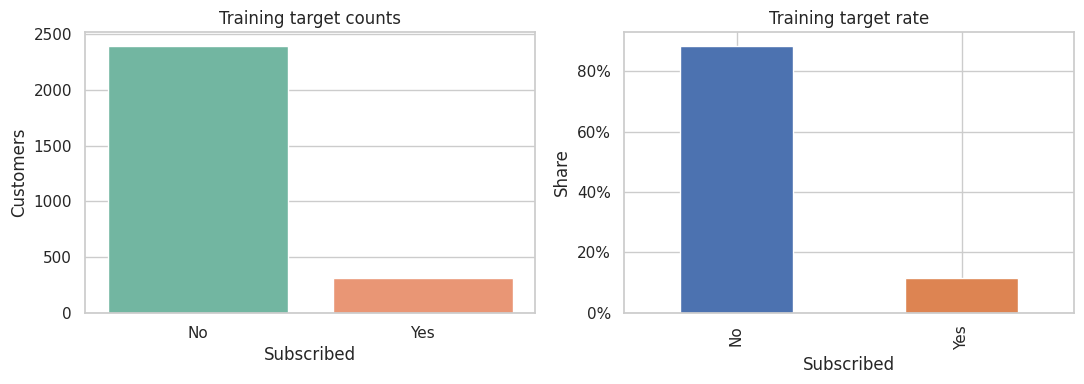

,percent
subscribed,
No,88.46
Yes,11.54


In [8]:
# Code Cell 08: Plot the target class distribution.

# Counts and percentages make the target imbalance visible.
# Place counts and percentages side by side so imbalance is visible in two ways.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=eda, x="subscribed", order=["No", "Yes"], ax=axes[0], palette="Set2")
axes[0].set(title="Training target counts", xlabel="Subscribed", ylabel="Customers")
# Calculate rates from training rows only, not from validation or test labels.
rates = eda["subscribed"].value_counts(normalize=True).reindex(["No", "Yes"])
# Use the same class order as the count chart for a direct comparison.
rates.plot(kind="bar", ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set(title="Training target rate", xlabel="Subscribed", ylabel="Share")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# Print exact percentages because bar height alone is not precise enough for reporting.
display((rates * 100).round(2).rename("percent").to_frame())

##### 1. Why did you pick the specific chart?

A count and percentage view was selected because class balance must be checked before choosing metrics or imbalance handling.

##### 2. What is/are the insight(s) found from the chart?

The training split contains 88.46% non-subscribers and 11.54% subscribers. Accuracy alone would therefore reward a model that mostly predicts `No`.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Yes. This result supports PR-AUC, positive-class precision, recall and F1 as the main evidence. It also justifies class weights without creating artificial customer rows.

#### Chart - 2: Numeric Feature Distributions

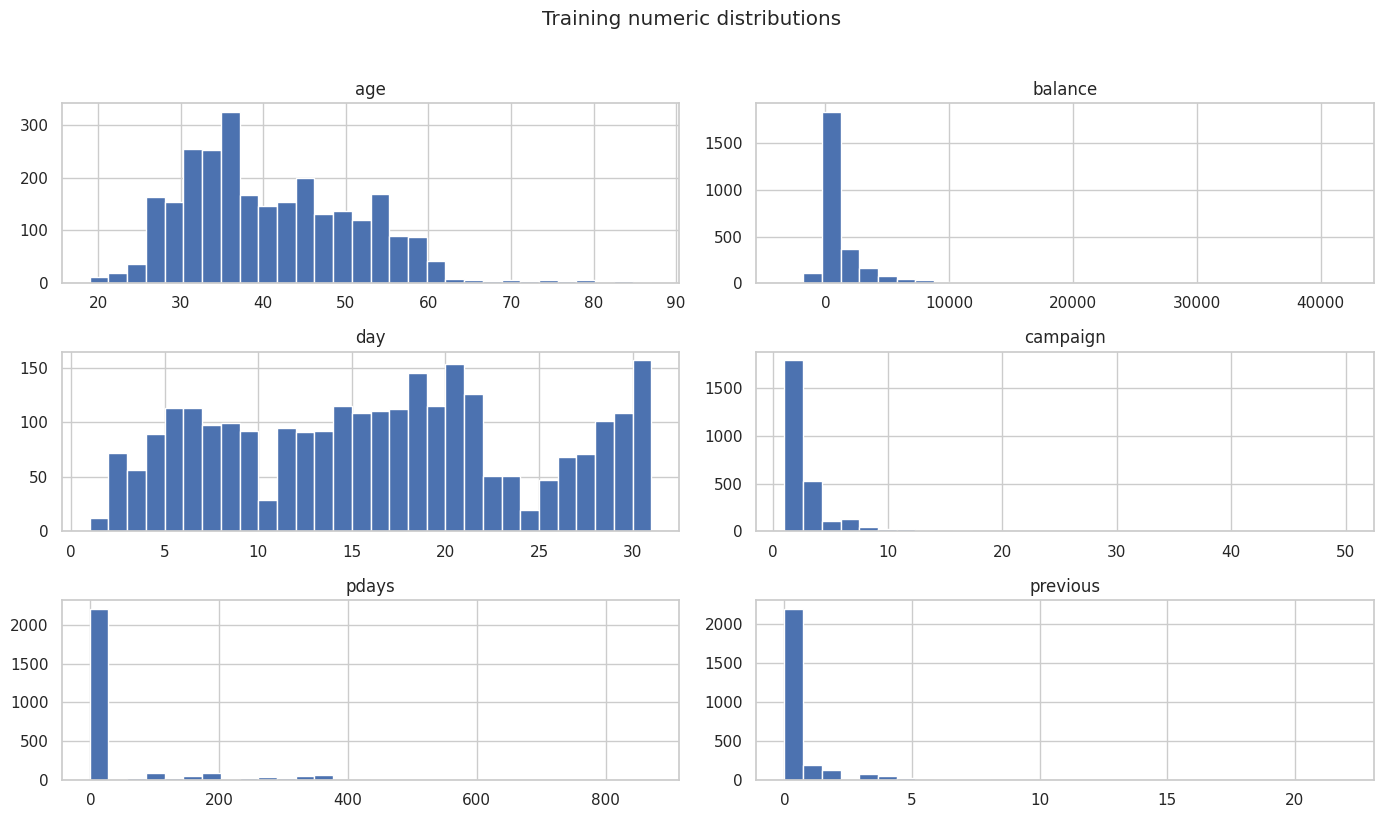

,iqr_lower_bound,iqr_upper_bound,potential_outliers,outlier_percent
feature,,,,
age,9.00,73.00,22,0.81
balance,-2009.75,3512.25,308,11.36
day,-9.00,39.00,0,0.00
campaign,-2.00,6.00,191,7.04
pdays,-1.00,-1.00,510,18.81
previous,0.00,0.00,510,18.81


In [9]:
# Code Cell 09: Review numeric distributions and potential outliers.

# Potential outliers are measured on training rows without deleting valid customers.
# Limit this diagnostic to the pre-call numeric fields used in later analysis.
numeric_columns = ["age", "balance", "day", "campaign", "pdays", "previous"]
# Histograms reveal skew and sentinel values without changing the data.
eda[numeric_columns].hist(
    bins=30,
    figsize=(14, 8),
    color="#4c72b0",
    edgecolor="white",
)
plt.suptitle("Training numeric distributions", y=1.02)
plt.tight_layout()
plt.show()

# Collect IQR flags as diagnostics; these flags are not used to delete customers.
outlier_rows = []
# Calculate each range independently because the feature scales are very different.
for column in numeric_columns:
    # IQR bounds come only from training data, which avoids looking at held-out distributions.
    q1, q3 = eda[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((eda[column] < lower) | (eda[column] > upper)).sum())
    outlier_rows.append({
        "feature": column,
        "iqr_lower_bound": lower,
        "iqr_upper_bound": upper,
        "potential_outliers": count,
        "outlier_percent": round(count / len(eda) * 100, 2),
    })

# The table helps distinguish real extreme values from coded states such as pdays=-1.
display(pd.DataFrame(outlier_rows).set_index("feature"))

##### 1. Why did you pick the specific chart?

Histograms show skew, extreme values and coded states such as `pdays=-1` more clearly than averages alone.

##### 2. What is/are the insight(s) found from the chart?

Balance has 308 IQR-flagged rows (11.36%) and campaign has 191 (7.04%). The 510 flags for both `pdays` and `previous` do not mean bad records: their quartiles collapse at -1 and 0 because most customers have no earlier contact history.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Yes. The output supports robust scaling inside the training pipeline instead of deleting rows. It also shows why a mechanical IQR rule would wrongly label ordinary previous-contact history as an outlier.

#### Chart - 3: Subscription Rate by Job

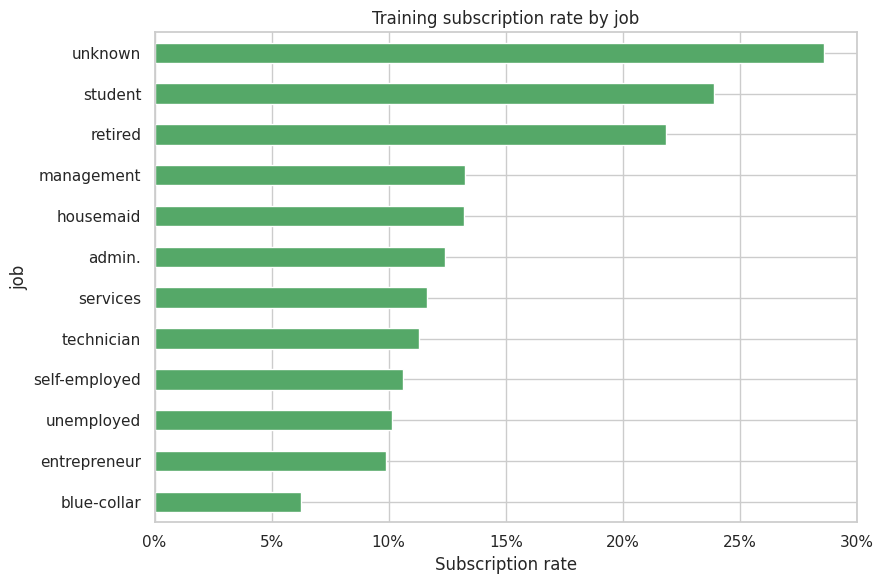

,customers,subscription_rate
job,,
blue-collar,575,0.0626
entrepreneur,101,0.0990
unemployed,79,0.1013
self-employed,113,0.1062
technician,470,0.1128
services,241,0.1162
admin.,290,0.1241
housemaid,68,0.1324
management,589,0.1324


In [10]:
# Code Cell 10: Compare subscription rate by job.

# Job groups are ranked with both sample size and conversion rate.
# Keep customer count beside rate so small job groups are not overinterpreted.
job_summary = eda.groupby("job", observed=False).agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
# Sort by rate to make the segment comparison easy to scan.
).sort_values("subscription_rate")
# A horizontal chart keeps all job labels readable.
job_summary["subscription_rate"].plot(kind="barh", figsize=(9, 6), color="#55a868")
plt.title("Training subscription rate by job")
plt.xlabel("Subscription rate")
plt.gca().xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# The exact table supports the written chart explanation.
display(job_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Job is a practical customer segment, but the chart also keeps sample size visible so small groups are not overvalued.

##### 2. What is/are the insight(s) found from the chart?

Retired and student groups show higher observed rates than blue-collar customers. The `unknown` group has the highest rate but contains only 21 training rows, so it is not a reliable campaign rule.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Job can support probability ranking, but the bank should not build a campaign around one small category. Larger samples and fairness review are needed.

#### Chart - 4: Subscription Rate by Age Group

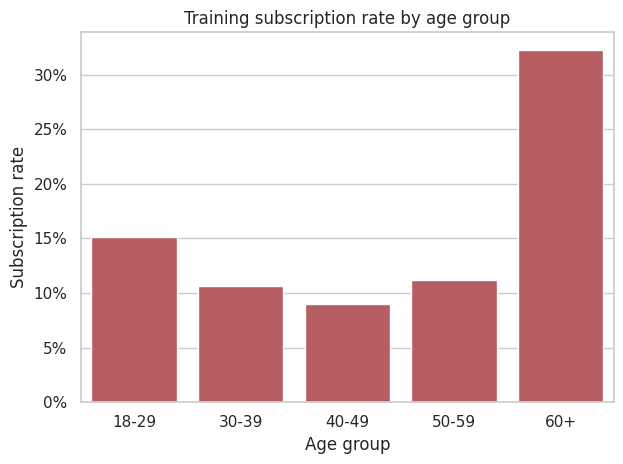

,customers,subscription_rate
age_group,,
18-29,291,0.1512
30-39,1093,0.1061
40-49,699,0.0901
50-59,536,0.1119
60+,93,0.3226


In [11]:
# Code Cell 11: Compare subscription rate by age group.

# Broad age bands avoid unstable conclusions from single ages.
# Aggregate the training target inside fixed age bands.
age_summary = eda.groupby("age_group", observed=False).agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
)
# Use one common axis so group rates remain directly comparable.
sns.barplot(data=age_summary.reset_index(), x="age_group", y="subscription_rate", color="#c44e52")
plt.title("Training subscription rate by age group")
plt.xlabel("Age group")
plt.ylabel("Subscription rate")
plt.gca().yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# Sample size is shown because the 60+ group is much smaller than the middle bands.
display(age_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Age bands make a nonlinear age pattern easier to read than individual ages.

##### 2. What is/are the insight(s) found from the chart?

The 60+ group has a 32.26% training subscription rate compared with 9.01% for ages 40-49, but the oldest group has only 93 rows.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Age can improve ranking, but it should not be used alone. The bank should review age-based targeting for fairness and sample-size stability.

#### Chart - 5: Education and Subscription

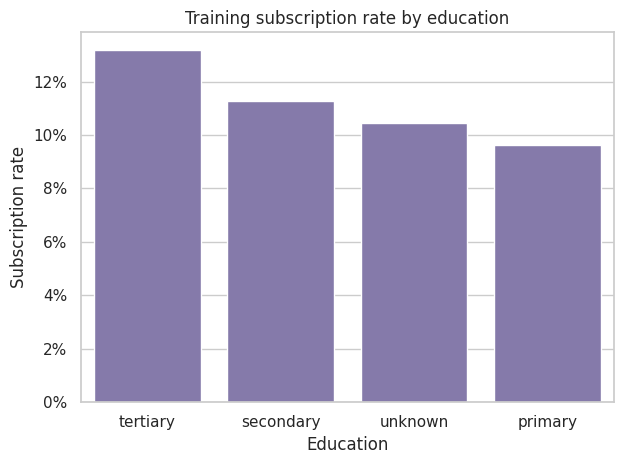

,customers,subscription_rate
education,,
tertiary,804,0.1318
secondary,1377,0.1126
unknown,115,0.1043
primary,416,0.0962


In [12]:
# Code Cell 12: Compare subscription rate by education.

# Unknown education remains a separate source-system category.
# Retain unknown education rather than assigning a guessed qualification.
education_summary = eda.groupby("education", observed=False).agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
# Order the categories by observed rate for a cleaner comparison.
).sort_values("subscription_rate", ascending=False)
# The chart shows association only; education is not treated as a cause.
sns.barplot(data=education_summary.reset_index(), x="education", y="subscription_rate", color="#8172b2")
plt.title("Training subscription rate by education")
plt.xlabel("Education")
plt.ylabel("Subscription rate")
plt.gca().yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# Exact counts keep modest differences in proper context.
display(education_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Education has a small number of readable categories and includes an explicit `unknown` value that should remain visible.

##### 2. What is/are the insight(s) found from the chart?

Tertiary education has a 13.18% training rate, while primary education has 9.62%. The differences are present but not large enough for a standalone rule.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Education may add a small amount of model information. Improving source-data completeness is more useful than guessing missing education levels.

#### Chart - 6: Marital Status and Subscription

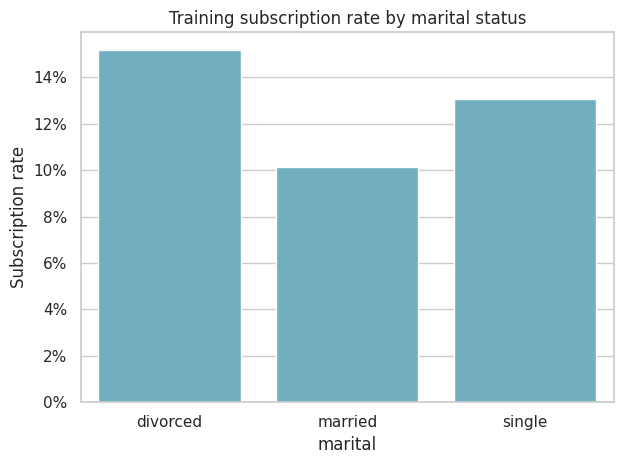

,customers,subscription_rate
marital,,
divorced,336,0.1518
married,1665,0.1015
single,711,0.1308


In [13]:
# Code Cell 13: Compare subscription rate by marital status.

# Observed group rates are compared without making causal claims.
# Calculate both group size and observed subscription rate.
marital_summary = eda.groupby("marital", observed=False).agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
)
# A single-color chart avoids implying that one group is automatically better.
sns.barplot(data=marital_summary.reset_index(), x="marital", y="subscription_rate", color="#64b5cd")
plt.title("Training subscription rate by marital status")
plt.ylabel("Subscription rate")
plt.gca().yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# The table supports a fairness-aware interpretation of the differences.
display(marital_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

A simple rate chart makes the three marital-status groups directly comparable.

##### 2. What is/are the insight(s) found from the chart?

Observed training rates are 15.18% for divorced, 13.08% for single and 10.15% for married customers.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

The variable can contribute to model ranking, but the differences are observational and must not be treated as causal or used for unfair exclusion.

#### Chart - 7: Housing and Personal Loans

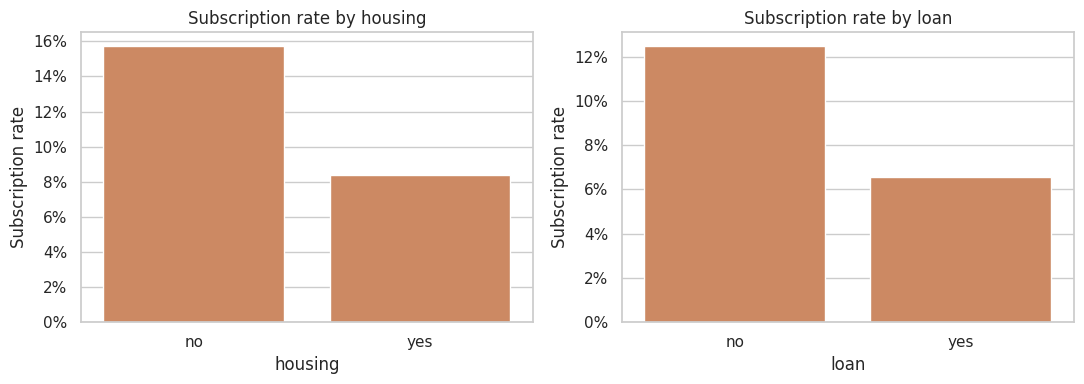

,indicator,housing,customers,subscription_rate,loan
0,housing,no,1164,0.1572,NaN
1,housing,yes,1548,0.0840,NaN
2,loan,NaN,2285,0.1247,no
3,loan,NaN,427,0.0656,yes


In [14]:
# Code Cell 14: Compare housing and personal loan outcomes.

# Two existing loan indicators are reviewed in one consistent summary.
# Store both loan summaries in one table for consistent reporting.
loan_summaries = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Use the same calculation and scale for housing and personal loans.
for column, axis in zip(["housing", "loan"], axes):
    # Count customers as well as outcomes so rate differences have sample-size context.
    summary = (
        eda.groupby(column)["y"]
        .agg(customers="size", subscription_rate=lambda values: values.eq("yes").mean())
        .reset_index()
    )
    # Label the source indicator before combining the two summaries.
    summary.insert(0, "indicator", column)
    loan_summaries.append(summary)
    # Plot rates while leaving exact values available in the table below.
    sns.barplot(data=summary, x=column, y="subscription_rate", ax=axis, color="#dd8452")
    axis.set(title=f"Subscription rate by {column}", ylabel="Subscription rate")
    axis.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

plt.tight_layout()
plt.show()
# The combined table makes the four rates easy to verify.
display(pd.concat(loan_summaries, ignore_index=True).round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Housing and personal-loan indicators are related financial obligations and are easier to compare in one figure.

##### 2. What is/are the insight(s) found from the chart?

Customers without a housing loan have a 15.72% training subscription rate, compared with 8.40% for customers with one. Personal-loan rates are 12.47% for `no` and 6.56% for `yes`.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

The result may help tailor campaign communication, but it does not measure income or affordability. Existing loans should remain supporting features, not automatic exclusion rules.

#### Chart - 8: Contact Channel

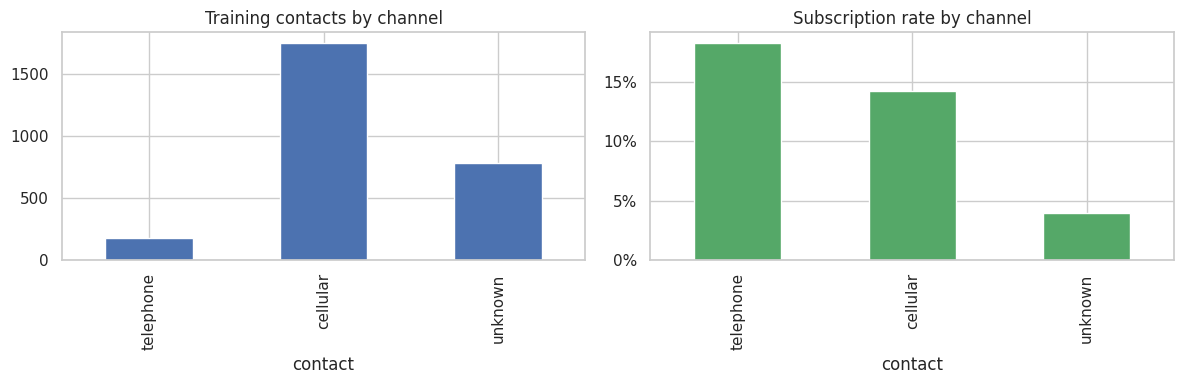

,customers,subscription_rate
contact,,
telephone,181,0.1823
cellular,1747,0.1425
unknown,784,0.0395


In [15]:
# Code Cell 15: Compare contact channel volume and conversion.

# Channel volume and conversion are shown together.
# Compare contact volume and success rate in the same grouped table.
contact_summary = eda.groupby("contact").agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
).sort_values("subscription_rate", ascending=False)
# Separate volume from rate because a common channel is not always the best-converting one.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# The first panel shows how much evidence supports each channel rate.
contact_summary["customers"].plot(kind="bar", ax=axes[0], color="#4c72b0", title="Training contacts by channel")
# The second panel focuses on the observed outcome difference.
contact_summary["subscription_rate"].plot(kind="bar", ax=axes[1], color="#55a868", title="Subscription rate by channel")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
display(contact_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Both contact volume and subscription rate are shown because the most-used channel is not automatically the best-converting channel.

##### 2. What is/are the insight(s) found from the chart?

Telephone and cellular rates are 18.23% and 14.25%, while the `unknown` contact group is only 3.95%. Telephone also has a much smaller sample than cellular.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Channel planning should combine expected conversion, customer consent and channel cost. The small telephone sample should be tested before changing operations.

#### Chart - 9: Campaign Month

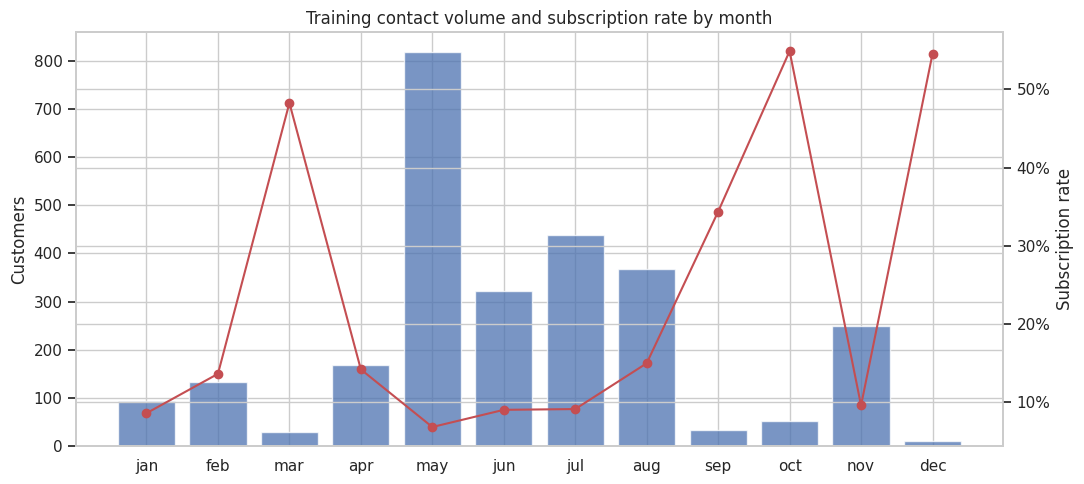

,customers,subscription_rate
month,,
jan,93,0.0860
feb,132,0.1364
mar,29,0.4828
apr,169,0.1420
may,819,0.0684
jun,321,0.0903
jul,438,0.0913
aug,367,0.1499
sep,32,0.3438


In [16]:
# Code Cell 16: Compare campaign activity by month.

# Calendar order is retained even though the file has no year field.
# Use calendar order rather than alphabetical month order.
month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
# Calculate volume and conversion together because either measure alone can mislead.
month_summary = eda.groupby("month").agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
).reindex(month_order).dropna()
fig, axis1 = plt.subplots(figsize=(11, 5))
# A second axis lets volume bars and rate points remain readable on different scales.
axis2 = axis1.twinx()
# Bars represent campaign volume for each month.
axis1.bar(month_summary.index, month_summary["customers"], color="#4c72b0", alpha=0.75)
# The line represents subscription rate and highlights small high-rate months.
axis2.plot(month_summary.index, month_summary["subscription_rate"], color="#c44e52", marker="o")
axis1.set(title="Training contact volume and subscription rate by month", ylabel="Customers")
axis2.set_ylabel("Subscription rate")
axis2.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
display(month_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

The combined chart separates monthly campaign volume from monthly conversion.

##### 2. What is/are the insight(s) found from the chart?

May has the highest training volume with 819 contacts but only 6.84% conversion. October, December and March show high rates, but each has a much smaller sample.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Staffing should not be based on conversion rate alone. Small-month results need more years of data before the bank changes campaign timing.

#### Chart - 10: Current Campaign Contact Count

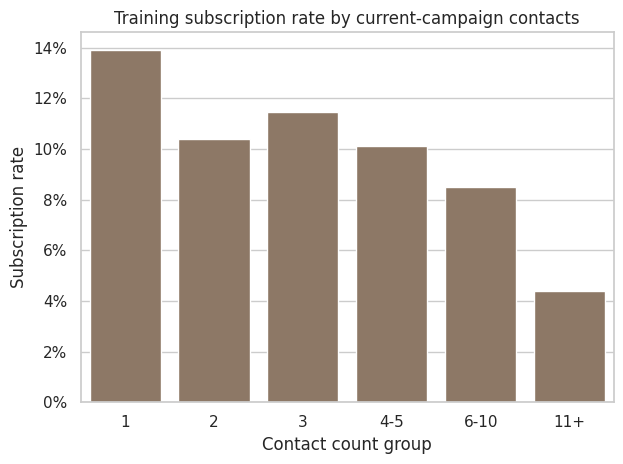

,customers,subscription_rate
campaign_group,,
1,1035,0.1391
2,760,0.1039
3,340,0.1147
4-5,297,0.1010
6-10,212,0.0849
11+,68,0.0441


In [17]:
# Code Cell 17: Compare conversion by current-campaign contact frequency.

# Sparse high-contact values are grouped for a more reliable comparison.
# Group the long contact-count tail so rare values do not create unstable bars.
eda["campaign_group"] = pd.cut(
    eda["campaign"], bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=["1", "2", "3", "4-5", "6-10", "11+"]
)
# Keep group counts next to rates before drawing conclusions.
campaign_summary = eda.groupby("campaign_group", observed=False).agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
)
# Ordered contact bands make the downward pattern easier to inspect.
sns.barplot(data=campaign_summary.reset_index(), x="campaign_group", y="subscription_rate", color="#937860")
plt.title("Training subscription rate by current-campaign contacts")
plt.xlabel("Contact count group")
plt.ylabel("Subscription rate")
plt.gca().yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# The table shows that the 11+ group has limited evidence.
display(campaign_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Contact counts are grouped so the long tail does not create many unstable single-value bars.

##### 2. What is/are the insight(s) found from the chart?

One-contact customers have a 13.91% rate, while the 11+ group has 4.41%. This is an association and may reflect difficult cases rather than harm caused by calling.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

The bank can test contact caps to reduce fatigue and cost, but a controlled experiment is needed before claiming a causal effect.

#### Chart - 11: Previous Campaign Outcome

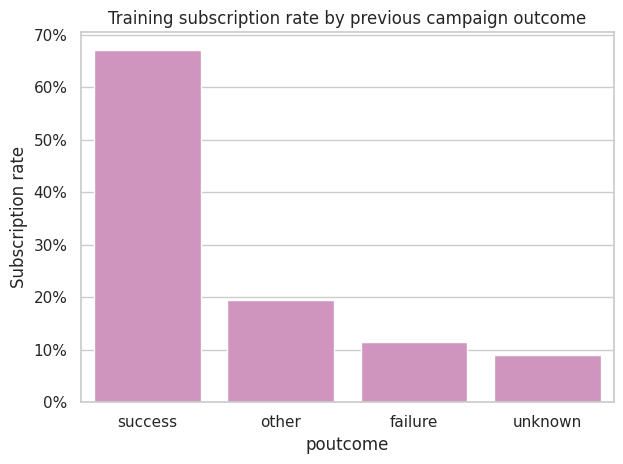

,customers,subscription_rate
poutcome,,
success,82,0.6707
other,123,0.1951
failure,305,0.1148
unknown,2202,0.0904


In [18]:
# Code Cell 18: Compare conversion by previous campaign outcome.

# Previous campaign states include unknown rather than hiding missing history.
# Keep unknown previous outcome because most customers have no recorded campaign result.
poutcome_summary = eda.groupby("poutcome").agg(
    customers=("y", "size"), subscription_rate=("y", lambda values: values.eq("yes").mean())
# Sort rates while retaining counts for the small success group.
).sort_values("subscription_rate", ascending=False)
# The chart highlights prior success without treating it as a guaranteed future outcome.
sns.barplot(data=poutcome_summary.reset_index(), x="poutcome", y="subscription_rate", color="#da8bc3")
plt.title("Training subscription rate by previous campaign outcome")
plt.ylabel("Subscription rate")
plt.gca().yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()
# Exact values support the later feature-importance discussion.
display(poutcome_summary.round({"subscription_rate": 4}))

##### 1. Why did you pick the specific chart?

Previous campaign outcome is a direct history variable and includes a large `unknown` group.

##### 2. What is/are the insight(s) found from the chart?

Customers with a previous success have a 67.07% training rate, compared with 9.04% for `unknown`. The success group contains only 82 rows.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Previous success is useful for prioritization, but new customers and customers without history must still have a fair route into the campaign.

#### Chart - 12: Account Balance by Outcome

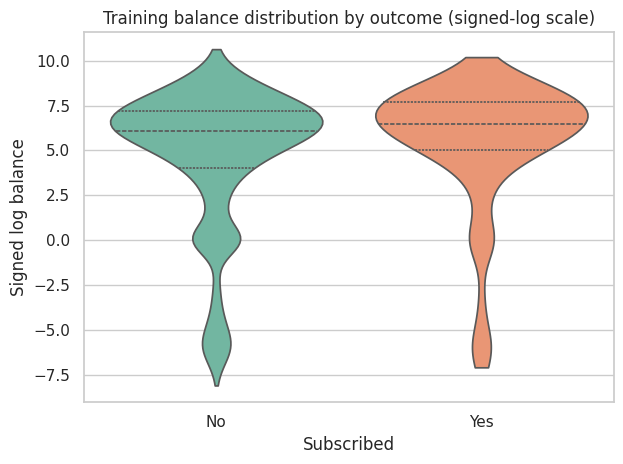

,count,median,mean
subscribed,,,
No,2399,425.0,1362.736140
Yes,313,661.0,1586.447284


In [19]:
# Code Cell 19: Compare account balance by subscription outcome.

# A signed-log scale keeps negative balances and compresses the long tail.
# Show distribution shape and quartiles instead of comparing means alone.
sns.violinplot(data=eda, x="subscribed", y="signed_log_balance", inner="quartile", cut=0, palette="Set2")
plt.title("Training balance distribution by outcome (signed-log scale)")
plt.xlabel("Subscribed")
# The transformed axis keeps negative balances and compresses extreme positives.
plt.ylabel("Signed log balance")
plt.tight_layout()
plt.show()
# Report original-balance medians and means so the transformed chart stays interpretable.
display(eda.groupby("subscribed")["balance"].agg(["count", "median", "mean"]))

##### 1. Why did you pick the specific chart?

A signed-log violin plot handles negative balances and the large positive tail while retaining the original ordering.

##### 2. What is/are the insight(s) found from the chart?

Subscribers have a higher median balance of 661 compared with 425 for non-subscribers, but the two distributions still overlap heavily.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Balance is a useful supporting feature, not a standalone eligibility rule. A high balance does not guarantee subscription.

#### Chart - 13: Call Duration (Post-Call EDA Only)

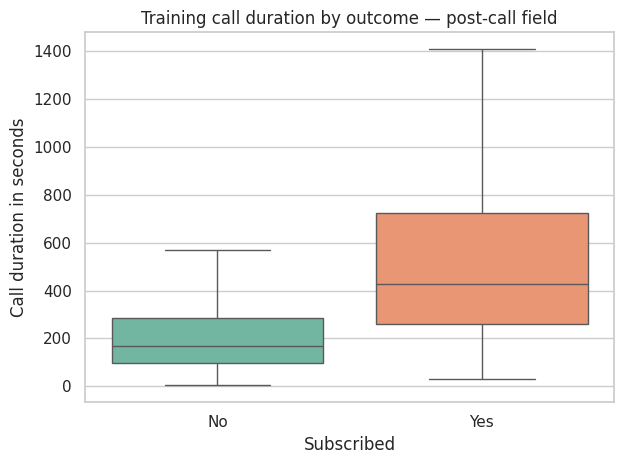

,count,median,mean
subscribed,,,
No,2399,167.0,228.270113
Yes,313,429.0,545.041534


In [20]:
# Code Cell 20: Review call duration as post-call EDA only.

# Duration is described after the call but excluded from every prediction model.
# Hide extreme plot points for readability without removing any rows from the data.
sns.boxplot(data=eda, x="subscribed", y="duration", showfliers=False, palette="Set2")
# Mark duration as post-call so it cannot be mistaken for a model input.
plt.title("Training call duration by outcome — post-call field")
plt.xlabel("Subscribed")
plt.ylabel("Call duration in seconds")
plt.tight_layout()
plt.show()
# The large median gap explains why duration would create unrealistic pre-call performance.
display(eda.groupby("subscribed")["duration"].agg(["count", "median", "mean"]))

##### 1. Why did you pick the specific chart?

The chart documents why a highly predictive-looking variable can still be invalid at the chosen prediction time.

##### 2. What is/are the insight(s) found from the chart?

Subscriber calls have a median duration of 429 seconds compared with 167 seconds for non-subscribers. This information is known only after the call.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

Excluding duration prevents misleading performance and makes the model usable for pre-call prioritization. It can be studied separately for post-call quality review.

#### Chart - 14: Numeric Correlation Heatmap

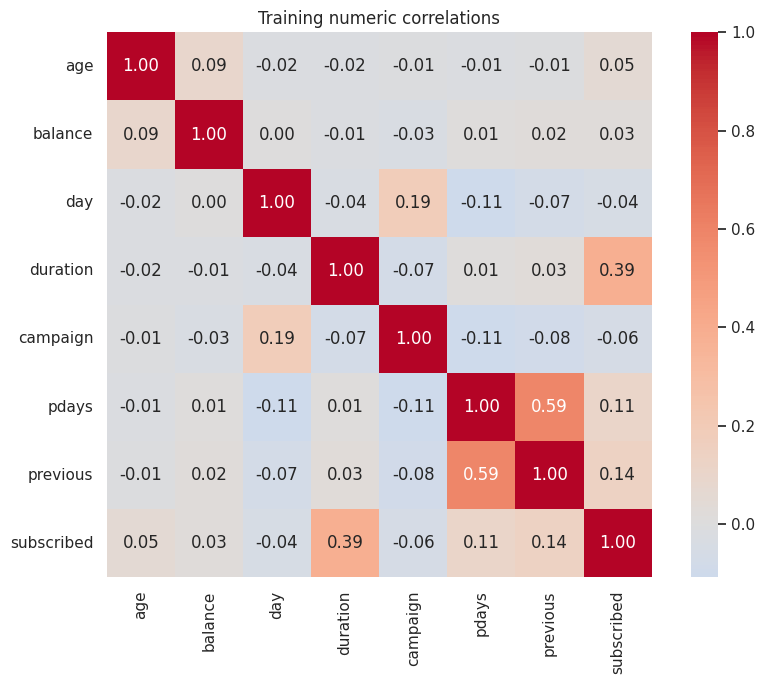

In [21]:
# Code Cell 21: Plot numeric correlations.

# The heatmap checks linear relationships and possible redundancy.
# Build the correlation table from training rows only.
corr_frame = eda[["age", "balance", "day", "duration", "campaign", "pdays", "previous"]].copy()
# Add a numeric target copy only for this descriptive heatmap.
corr_frame["subscribed"] = eda["y"].eq("yes").astype(int)
plt.figure(figsize=(9, 7))
# Center the color scale at zero so positive and negative relationships are comparable.
sns.heatmap(corr_frame.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
# Duration remains visible here only to document the leakage risk.
plt.title("Training numeric correlations")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap summarizes linear relationships among numeric fields and the training target.

##### 2. What is/are the insight(s) found from the chart?

Most pre-call numeric correlations are weak. Duration has the clearest target relationship, but it is deliberately excluded because it is post-call information.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

The weak individual relationships support combining several features in a model instead of relying on one numeric rule.

#### Chart - 15: Selected Numeric Pair Plot

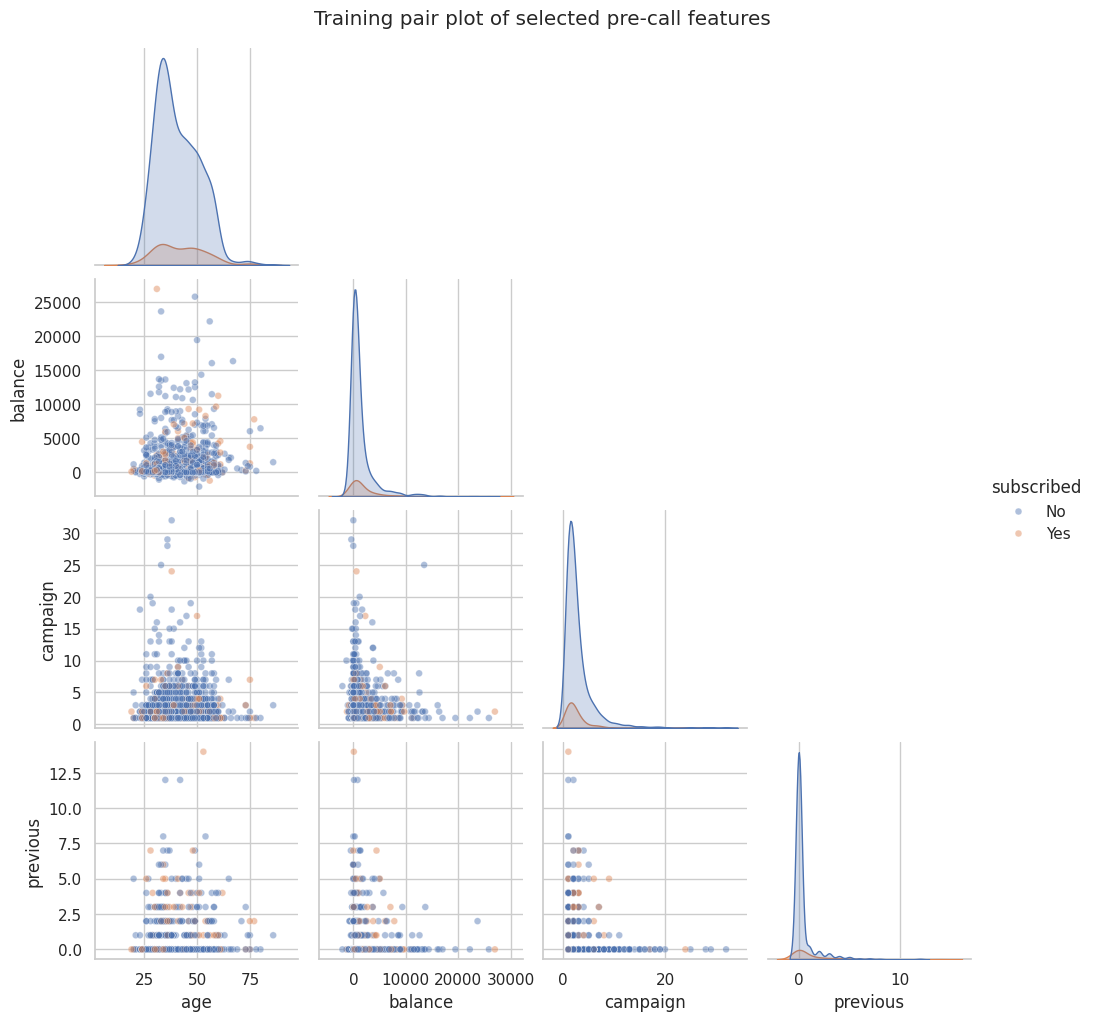

In [22]:
# Code Cell 22: Plot selected pairwise numeric patterns.

# A fixed training sample keeps the pair plot readable and reproducible.
# Use a fixed random sample to keep rendering time and visual density manageable.
pair_sample = eda.sample(min(1200, len(eda)), random_state=RANDOM_STATE)
# Compare a small set of pre-call numeric fields rather than every possible pair.
pair_grid = sns.pairplot(
    pair_sample,
    vars=["age", "balance", "campaign", "previous"],
    # Color by outcome to check whether simple two-feature separation exists.
    hue="subscribed",
    corner=True,
    plot_kws={"alpha": 0.45, "s": 24},
)
# Place one title above the complete grid instead of repeating titles in each panel.
pair_grid.fig.suptitle("Training pair plot of selected pre-call features", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A sampled pair plot checks overlap and simple interactions without making the notebook slow or unreadable.

##### 2. What is/are the insight(s) found from the chart?

Subscribers and non-subscribers overlap across age, balance, campaign and previous-contact views. No clean two-feature boundary is visible.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that may lead to negative growth? Justify with a specific reason.

A multivariable probability model is appropriate, but the overlap also shows why predictions must be treated as uncertain rankings rather than guarantees.

## 5. Hypothesis Testing

All tests use only the training split. A significance level of 0.05 is used. Statistical significance is not the same as business importance or causality.

### Hypothesis 1 — Contact Type and Subscription

In [23]:
# Code Cell 23: Test contact type and subscription association.

# Chi-square significance is reported with Cramer's V effect size.
# Create observed counts for each channel and target combination.
contact_table = pd.crosstab(train_df["contact"], train_df["y"])
# Test whether the observed table differs from independence.
chi2, p_value_contact, dof, expected = chi2_contingency(contact_table)
# Use the same training-table size in the effect-size calculation.
sample_size = contact_table.to_numpy().sum()
minimum_dimension = min(contact_table.shape) - 1
# Cramer's V shows relationship strength, which a small p-value cannot show by itself.
cramers_v = np.sqrt(chi2 / (sample_size * minimum_dimension))

display(contact_table)
print({
    "chi_square": round(float(chi2), 4),
    "degrees_of_freedom": int(dof),
    "p_value": float(p_value_contact),
    "cramers_v": round(float(cramers_v), 4),
})
# Report the statistical decision, then interpret magnitude separately in markdown.
print("Decision:", "Reject H0" if p_value_contact < 0.05 else "Fail to reject H0")

y,no,yes
contact,,
cellular,1498,249
telephone,148,33
unknown,753,31


{'chi_square': 64.726, 'degrees_of_freedom': 2, 'p_value': 8.809018054617439e-15, 'cramers_v': 0.1545}
Decision: Reject H0


The p-value is **8.81e-15**, so contact type and subscription are associated in the training data. Cramer's V is about **0.154**, which is small-to-moderate rather than a strong relationship. Channel should therefore remain one feature among several.

**H0:** Contact type and subscription are independent.  
**H1:** Contact type and subscription are associated.  
The result is interpreted as association only; channel assignment may itself depend on other customer characteristics.

### Hypothesis 2 — Balance Distribution and Subscription

In [24]:
# Code Cell 24: Test balance difference by subscription outcome.

# Mann-Whitney U is used because balance is strongly skewed.
# Separate training balances by outcome without inspecting held-out labels.
balance_yes = train_df.loc[train_df["y"].eq("yes"), "balance"]
balance_no = train_df.loc[train_df["y"].eq("no"), "balance"]
# Use a rank-based test because balance is highly skewed.
u_balance, p_value_balance = mannwhitneyu(
    balance_yes,
    balance_no,
    alternative="two-sided",
)
# Rank-biserial correlation adds direction and practical magnitude.
balance_effect = 2 * u_balance / (len(balance_yes) * len(balance_no)) - 1

# Print medians, significance, and effect size together for a complete interpretation.
print({
    "yes_median": float(balance_yes.median()),
    "no_median": float(balance_no.median()),
    "u_statistic": round(float(u_balance), 4),
    "p_value": float(p_value_balance),
    "rank_biserial": round(float(balance_effect), 4),
})
print("Decision:", "Reject H0" if p_value_balance < 0.05 else "Fail to reject H0")

{'yes_median': 661.0, 'no_median': 425.0, 'u_statistic': 425223.0, 'p_value': 0.0001327014516825929, 'rank_biserial': 0.1326}
Decision: Reject H0


Subscribed customers have a median balance of **661**, compared with **425** for non-subscribers. The p-value is **0.000133**, but rank-biserial correlation is only about **0.133**, showing a small distribution effect with substantial overlap.

**H0:** Balance distributions are the same for subscribed and non-subscribed customers.  
**H1:** The balance distributions differ.  
The non-parametric test is appropriate for the strongly skewed balance variable.

### Hypothesis 3 — Campaign Contacts and Subscription

In [25]:
# Code Cell 25: Test campaign-contact difference by outcome.

# Distribution difference is reported with rank-biserial effect size.
# Compare full contact-count distributions even when the medians are equal.
campaign_yes = train_df.loc[train_df["y"].eq("yes"), "campaign"]
campaign_no = train_df.loc[train_df["y"].eq("no"), "campaign"]
# The rank-based test does not assume normal contact counts.
u_campaign, p_value_campaign = mannwhitneyu(
    campaign_yes,
    campaign_no,
    alternative="two-sided",
)
# A signed effect size shows which group tends to have larger ranks.
campaign_effect = 2 * u_campaign / (len(campaign_yes) * len(campaign_no)) - 1

# Keep p-value and effect size side by side to avoid overstating significance.
print({
    "yes_median": float(campaign_yes.median()),
    "no_median": float(campaign_no.median()),
    "u_statistic": round(float(u_campaign), 4),
    "p_value": float(p_value_campaign),
    "rank_biserial": round(float(campaign_effect), 4),
})
print("Decision:", "Reject H0" if p_value_campaign < 0.05 else "Fail to reject H0")

{'yes_median': 2.0, 'no_median': 2.0, 'u_statistic': 334668.0, 'p_value': 0.0011034477700549018, 'rank_biserial': -0.1086}
Decision: Reject H0


Both groups have a median of **2 contacts**, yet the full distributions differ with p-value **0.00110**. Rank-biserial correlation is about **-0.109**, a small effect. Repeated contact should not be described as a proven cause of lower conversion.

**H0:** Campaign-contact distributions are the same for the two outcome groups.  
**H1:** They differ.  
Even when a difference is significant, repeated contact should not be assumed to cause lower or higher conversion.

## 6. Feature Engineering and Data Preprocessing


In [26]:
# Code Cell 26: Build prediction-time-safe model features.

# Raw model inputs contain only fields known before the current call begins.
raw_feature_columns = [
    column for column in df.columns if column not in {"y", "duration"}
]

# Keep all deterministic feature logic in one function so the saved pipeline can repeat it.
def prepare_features(frame):
    features = frame.copy()

    # A value of -1 means the customer was never contacted in an earlier campaign.
    if "pdays" in features.columns:
        features["previously_contacted"] = np.where(features["pdays"].eq(-1), "no", "yes")
        features["days_since_previous_contact"] = features["pdays"].where(features["pdays"].ge(0), np.nan)
        # The coded -1 is removed after its meaning is represented explicitly.
        features = features.drop(columns="pdays")

    # Signed log keeps negative balances while reducing the influence of the long positive tail.
    if "balance" in features.columns:
        features["signed_log_balance"] = np.sign(features["balance"]) * np.log1p(features["balance"].abs())

    # Log counts make the long campaign tails easier for the linear model to use.
    if "campaign" in features.columns:
        features["log_campaign"] = np.log1p(features["campaign"])
    if "previous" in features.columns:
        features["log_previous"] = np.log1p(features["previous"])
    if {"campaign", "previous"}.issubset(features.columns):
        features["contact_intensity"] = features["campaign"] + features["previous"]
        features["log_contact_intensity"] = np.log1p(features["contact_intensity"])

    # Month stays categorical, while sine and cosine preserve its circular calendar order.
    if "month" in features.columns:
        month_number = features["month"].map({
            "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
            "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12,
        })
        features["month_sin"] = np.sin(2 * np.pi * month_number / 12)
        features["month_cos"] = np.cos(2 * np.pi * month_number / 12)

    # Day remains available in its original form and also receives a smooth monthly position.
    if "day" in features.columns:
        features["day_sin"] = np.sin(2 * np.pi * features["day"] / 31)
        features["day_cos"] = np.cos(2 * np.pi * features["day"] / 31)

    # These flags make important source-system states explicit without using the target.
    if "poutcome" in features.columns:
        features["previous_campaign_success"] = features["poutcome"].eq("success").astype(int)
    if "contact" in features.columns:
        features["contact_channel_known"] = features["contact"].ne("unknown").astype(int)

    return features


# Development data uses 80% of the file; the final test remains separate.
development_df = pd.concat([train_df, validation_df]).sort_index()
X_development_raw = development_df[raw_feature_columns].copy()
X_test_raw = test_df[raw_feature_columns].copy()
y_development = development_df["y"].map({"no": 0, "yes": 1})
y_test = test_df["y"].map({"no": 0, "yes": 1})

# Inspect the engineered schema without fitting any model or preprocessing statistics.
engineered_example = prepare_features(X_development_raw)
numeric_features = engineered_example.select_dtypes(include="number").columns.tolist()
categorical_features = engineered_example.select_dtypes(exclude="number").columns.tolist()

print("Development rows:", len(X_development_raw))
print("Sealed test rows:", len(X_test_raw))
print("Raw pre-call features:", len(raw_feature_columns))
print("Engineered features:", engineered_example.shape[1])
print("Excluded from every model: duration")


Development rows: 3616
Sealed test rows: 905
Raw pre-call features: 15
Engineered features: 27
Excluded from every model: duration


The feature builder uses only pre-call information. It represents the special `pdays=-1` state explicitly, reduces skew in balance and contact counts, and adds calendar features without using the target. The same function is placed inside every fitted pipeline so training and later scoring follow the same steps.


In [27]:
# Code Cell 27: Define reusable training-fitted preprocessing.

# Build a fresh preprocessor whenever an experiment uses a different feature subset.
def make_preprocessor(numeric_columns, categorical_columns):
    numeric_pipeline = Pipeline([
        # Fold-specific medians protect future scoring from occasional blank numeric values.
        ("imputer", SimpleImputer(strategy="median")),
        # Robust scaling is less sensitive to the long balance and contact-count tails.
        ("scaler", RobustScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # Unseen categories are ignored instead of stopping a future prediction.
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])


preprocessor = make_preprocessor(numeric_features, categorical_features)
feature_builder = FunctionTransformer(prepare_features, validate=False)

print("Feature engineering and preprocessing are defined but not fitted.")
print("Every cross-validation fold will fit its own imputers, scaler, encoder, and model.")


Feature engineering and preprocessing are defined but not fitted.
Every cross-validation fold will fit its own imputers, scaler, encoder, and model.


Preprocessing remains inside the modeling pipeline. This prevents development-fold information from setting imputation values, scaling ranges or one-hot categories in another fold. CatBoost later uses the engineered dataframe directly because it can learn from categorical values without one-hot encoding.


## 7. Machine Learning Model Implementation


In [28]:
# Code Cell 28: Define evaluation metrics and cross-validation.

# Keep every candidate on the same metric definitions and reproducible folds.
def classification_metrics(y_true, probabilities, threshold=0.50):
    predictions = (probabilities >= threshold).astype(int)  # Convert scores only at the chosen cutoff.
    return {
        "PR-AUC": average_precision_score(y_true, probabilities),  # Primary imbalanced-class ranking metric.
        "ROC-AUC": roc_auc_score(y_true, probabilities),  # Secondary all-threshold ranking metric.
        "Precision": precision_score(y_true, predictions, zero_division=0),  # Share of calls that convert.
        "Recall": recall_score(y_true, predictions, zero_division=0),  # Share of subscribers detected.
        "F1": f1_score(y_true, predictions, zero_division=0),  # Balance between precision and recall.
        "Balanced accuracy": balanced_accuracy_score(y_true, predictions),  # Gives both classes equal weight.
    }


def probability_to_logit(probabilities):
    # Logistic calibration works more naturally on log-odds than on compressed probabilities.
    clipped = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(clipped / (1 - clipped))


model_cv = RepeatedStratifiedKFold(
    n_splits=5,  # Five folds keep enough positive examples in every validation part.
    n_repeats=2,  # A second arrangement reduces dependence on one lucky split.
    random_state=RANDOM_STATE,
)
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 1,  # Different folds are used for OOF scoring.
)

print("Primary selection metric: repeated-CV PR-AUC")
print("Model selection folds: 5 folds x 2 repetitions")
print("Calibration: cross-fitted logistic probability layer")


Primary selection metric: repeated-CV PR-AUC
Model selection folds: 5 folds x 2 repetitions
Calibration: cross-fitted logistic probability layer


### Model 0 — Dummy Baseline


In [29]:
# Code Cell 29: Measure the prior-probability baseline.

# The dummy model follows the same feature path so the comparison remains fair.
dummy_model = Pipeline([
    ("features", clone(feature_builder)),  # Applies the same deterministic feature rules.
    ("preprocessor", clone(preprocessor)),  # Fits fold-specific imputers and encoding.
    ("model", DummyClassifier(strategy="prior")),  # Predicts only the training prevalence.
])

dummy_cv_scores = cross_val_score(
    dummy_model,
    X_development_raw,
    y_development,
    scoring="average_precision",  # Uses the same primary score as learned candidates.
    cv=model_cv,
    n_jobs=-1,  # Reuses available Colab CPU cores for independent folds.
)
dummy_model.fit(X_development_raw, y_development)  # Keeps a fitted baseline for the comparison table.

print("Mean repeated-CV PR-AUC:", round(dummy_cv_scores.mean(), 4))
print("Fold standard deviation:", round(dummy_cv_scores.std(), 4))


Mean repeated-CV PR-AUC: 0.1153
Fold standard deviation: 0.0006


The dummy baseline records mean PR-AUC **0.1153** with very small fold variation of **0.0006**. This is almost the same as the subscriber prevalence, so it confirms that a model predicting only the class rate has little ranking value. Every learned model improves clearly on this reference.


### Model 1 — Class-Weighted Logistic Regression


In [30]:
# Code Cell 30: Tune Logistic Regression with repeated cross-validation.

# The linear benchmark checks whether mostly additive relationships are sufficient.
logistic_pipeline = Pipeline([
    ("features", clone(feature_builder)),  # Rebuilds safe engineered fields inside every fold.
    ("preprocessor", clone(preprocessor)),  # Scales numbers and one-hot encodes categories.
    ("model", LogisticRegression(
        class_weight="balanced",  # Gives subscriber errors more influence during fitting.
        max_iter=3000,  # Allows regularized optimization to converge on the wide encoded matrix.
        random_state=RANDOM_STATE,
    )),
])

logistic_search = GridSearchCV(
    logistic_pipeline,
    param_grid={"model__C": [0.05, 0.20, 1.00, 5.00]},  # Tests stronger to weaker regularization.
    scoring="average_precision",
    cv=model_cv,
    n_jobs=-1,
    return_train_score=False,  # Avoids storing results that are not used for selection.
)
logistic_search.fit(X_development_raw, y_development)

logistic_std = logistic_search.cv_results_["std_test_score"][logistic_search.best_index_]
print("Best mean repeated-CV PR-AUC:", round(logistic_search.best_score_, 4))
print("Fold standard deviation:", round(logistic_std, 4))
print("Best parameters:", logistic_search.best_params_)


Best mean repeated-CV PR-AUC: 0.3607
Fold standard deviation: 0.0612
Best parameters: {'model__C': 0.2}


Logistic Regression selects **C=0.20** and reaches mean repeated-CV PR-AUC **0.3607**. Its fold standard deviation is **0.0612**, the largest among the learned candidates. The linear model captures useful signal, but its performance changes more across folds than the tree-based models.


### Model 2 — Class-Weighted Random Forest


In [31]:
# Code Cell 31: Tune Random Forest with repeated cross-validation.

# The forest captures nonlinear rules while leaf controls reduce minority-class overfitting.
forest_pipeline = Pipeline([
    ("features", clone(feature_builder)),  # Keeps raw-to-engineered conversion inside validation folds.
    ("preprocessor", clone(preprocessor)),  # Produces one consistent numeric matrix for all trees.
    ("model", RandomForestClassifier(
        n_estimators=300,  # Enough trees to stabilize probability ranking on this small dataset.
        class_weight="balanced_subsample",  # Rebalances classes separately for each bootstrap sample.
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

forest_search = GridSearchCV(
    forest_pipeline,
    param_grid={
        "model__max_depth": [8, None],  # Compares controlled depth with fully grown trees.
        "model__min_samples_leaf": [2, 5],  # Larger leaves make probabilities less extreme.
        "model__max_features": ["sqrt"],  # Adds diversity between trees.
    },
    scoring="average_precision",
    cv=model_cv,
    n_jobs=-1,
    return_train_score=False,
)
forest_search.fit(X_development_raw, y_development)

forest_std = forest_search.cv_results_["std_test_score"][forest_search.best_index_]
print("Best mean repeated-CV PR-AUC:", round(forest_search.best_score_, 4))
print("Fold standard deviation:", round(forest_std, 4))
print("Best parameters:", forest_search.best_params_)


Best mean repeated-CV PR-AUC: 0.372
Fold standard deviation: 0.0413
Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5}


Random Forest achieves the highest mean repeated-CV PR-AUC at **0.3720**, with fold standard deviation **0.0413**. The selected forest uses unrestricted depth, square-root feature sampling and minimum leaf size **5**. The larger leaf size helps control very small, unstable rules even though individual trees can grow deeply.


### Model 3 — Histogram Gradient Boosting


In [32]:
# Code Cell 32: Tune Histogram Gradient Boosting with repeated cross-validation.

# Boosting adds small nonlinear corrections instead of building independent trees.
boosting_pipeline = Pipeline([
    ("features", clone(feature_builder)),  # Repeats feature construction inside each fold.
    ("preprocessor", clone(preprocessor)),  # Supplies the dense matrix required by this estimator.
    ("model", HistGradientBoostingClassifier(
        class_weight="balanced",  # Prevents the majority class from dominating the loss.
        max_iter=250,  # Holds iteration count fixed while other complexity controls are tuned.
        random_state=RANDOM_STATE,
    )),
])

boosting_search = GridSearchCV(
    boosting_pipeline,
    param_grid={
        "model__learning_rate": [0.03, 0.08],  # Tests slower and faster correction sizes.
        "model__max_leaf_nodes": [15, 31],  # Limits interaction complexity per tree.
        "model__l2_regularization": [0.0, 1.0],  # Checks whether shrinkage improves stability.
    },
    scoring="average_precision",
    cv=model_cv,
    n_jobs=-1,
    return_train_score=False,
)
boosting_search.fit(X_development_raw, y_development)

boosting_std = boosting_search.cv_results_["std_test_score"][boosting_search.best_index_]
print("Best mean repeated-CV PR-AUC:", round(boosting_search.best_score_, 4))
print("Fold standard deviation:", round(boosting_std, 4))
print("Best parameters:", boosting_search.best_params_)


Best mean repeated-CV PR-AUC: 0.3463
Fold standard deviation: 0.0374
Best parameters: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.03, 'model__max_leaf_nodes': 15}


Histogram Gradient Boosting selects learning rate **0.03**, **15** leaf nodes and no extra L2 regularization. Its mean CV PR-AUC is **0.3463 ± 0.0374**, which still beats the dummy baseline but is the lowest result among the four learned models.


### Model 4 — Native-Categorical CatBoost


In [33]:
# Code Cell 33: Tune CatBoost on native categorical features.

# CatBoost receives the engineered dataframe directly, avoiding one-hot expansion.
catboost_pipeline = Pipeline([
    ("features", clone(feature_builder)),  # Returns a named dataframe CatBoost can read directly.
    ("model", CatBoostClassifier(
        loss_function="Logloss",  # Fits binary class probabilities.
        eval_metric="PRAUC",  # Tracks the same imbalance-aware ranking objective.
        auto_class_weights="Balanced",  # Learns class weights from each training fold.
        iterations=400,  # Keeps runtime manageable during repeated tuning.
        l2_leaf_reg=5.0,
        random_seed=RANDOM_STATE,
        verbose=False,  # Prevents hundreds of training lines from crowding the notebook.
        allow_writing_files=False,  # Avoids temporary CatBoost folders in Google Drive.
        thread_count=-1,
    )),
])

catboost_search = GridSearchCV(
    catboost_pipeline,
    param_grid={
        "model__depth": [4, 6],  # Tests compact and moderately deep interaction trees.
        "model__learning_rate": [0.03, 0.08],
        "model__l2_leaf_reg": [3.0, 7.0],  # Controls leaf-value regularization.
    },
    scoring="average_precision",
    cv=model_cv,
    n_jobs=1,  # CatBoost already parallelizes each individual fit.
    return_train_score=False,
)

# Fit-time category names avoid the CatBoost/scikit-learn constructor clone conflict.
catboost_search.fit(
    X_development_raw,
    y_development,
    model__cat_features=categorical_features,
)

catboost_std = catboost_search.cv_results_["std_test_score"][catboost_search.best_index_]
print("Best mean repeated-CV PR-AUC:", round(catboost_search.best_score_, 4))
print("Fold standard deviation:", round(catboost_std, 4))
print("Best parameters:", catboost_search.best_params_)


Best mean repeated-CV PR-AUC: 0.3695
Fold standard deviation: 0.0428
Best parameters: {'model__depth': 4, 'model__l2_leaf_reg': 3.0, 'model__learning_rate': 0.03}


CatBoost reaches mean repeated-CV PR-AUC **0.3695** with fold standard deviation **0.0428** using depth **4**, learning rate **0.03** and L2 leaf regularization **3**. It finishes only **0.0025** behind Random Forest, so both models should be treated as close competitors rather than clearly different in quality.


### Repeated-CV Model Comparison and Final Selection


,Model,Mean CV PR-AUC,CV standard deviation
0,Random Forest,0.3720,0.0413
1,CatBoost,0.3695,0.0428
2,Logistic Regression,0.3607,0.0612
3,Histogram Gradient Boosting,0.3463,0.0374
4,Dummy baseline,0.1153,0.0006


Best single model by mean repeated-CV PR-AUC: Random Forest


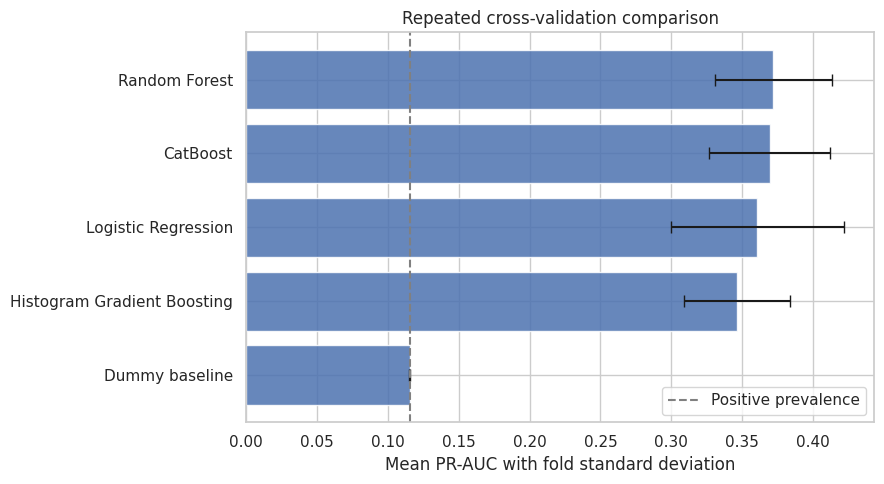


**Random Forest** ranks first with mean repeated-CV PR-AUC **0.3720**. **CatBoost** follows at **0.3695**. Their difference should be read beside fold variation, so the first rank does not automatically prove a large practical advantage.


In [34]:
# Code Cell 34: Compare repeated-CV performance and lock the best single model.

# Store development evidence only; no held-out labels are used in this comparison.
candidate_models = {
    "Dummy baseline": dummy_model,
    "Logistic Regression": logistic_search.best_estimator_,
    "Random Forest": forest_search.best_estimator_,
    "Histogram Gradient Boosting": boosting_search.best_estimator_,
    "CatBoost": catboost_search.best_estimator_,
}
cv_summary = pd.DataFrame({
    "Model": list(candidate_models),
    "Mean CV PR-AUC": [
        dummy_cv_scores.mean(),
        logistic_search.best_score_,
        forest_search.best_score_,
        boosting_search.best_score_,
        catboost_search.best_score_,
    ],
    "CV standard deviation": [
        dummy_cv_scores.std(),
        logistic_std,
        forest_std,
        boosting_std,
        catboost_std,
    ],
}).sort_values("Mean CV PR-AUC", ascending=False).reset_index(drop=True)

display(cv_summary.round(4))

selected_name = cv_summary.loc[0, "Model"]  # PR-AUC remains the declared single-model rule.
selected_model = candidate_models[selected_name]  # This fitted pipeline becomes the robustness anchor.
blend_model_names = ["Logistic Regression", "Random Forest", "CatBoost"]  # Diverse blend components.
oof_model_names = list(dict.fromkeys([selected_name] + blend_model_names))  # Avoids duplicate fold work.
print("Best single model by mean repeated-CV PR-AUC:", selected_name)


def fresh_candidate_pipeline(model_name):
    # Every OOF fold needs a clean estimator rather than a copy of fitted state.
    template = candidate_models[model_name]
    if model_name == "CatBoost":
        catboost_parameters = template.named_steps["model"].get_params().copy()
        catboost_parameters.pop("cat_features", None)  # Category names are supplied only during fit.
        return Pipeline([
            ("features", clone(feature_builder)),
            ("model", CatBoostClassifier(**catboost_parameters)),
        ])
    return clone(template)


def fit_candidate_pipeline(model, model_name, X_fit, y_fit):
    fit_arguments = {}
    if model_name == "CatBoost":
        fit_arguments["model__cat_features"] = categorical_features  # Preserves native categories.
    model.fit(X_fit, y_fit, **fit_arguments)
    return model


# Error bars show that a tiny mean difference may be smaller than fold variation.
plot_table = cv_summary.sort_values("Mean CV PR-AUC")
fig, axis = plt.subplots(figsize=(9, 5))
axis.barh(
    plot_table["Model"],
    plot_table["Mean CV PR-AUC"],
    xerr=plot_table["CV standard deviation"],
    color="#4c72b0",
    alpha=0.85,
    capsize=4,
)
axis.axvline(y_development.mean(), color="grey", linestyle="--", label="Positive prevalence")
axis.set_title("Repeated cross-validation comparison")
axis.set_xlabel("Mean PR-AUC with fold standard deviation")
axis.legend()
plt.tight_layout()
plt.show()

runner_up = cv_summary.iloc[1]
display(Markdown(f'''
**{selected_name}** ranks first with mean repeated-CV PR-AUC **{cv_summary.loc[0, 'Mean CV PR-AUC']:.4f}**. **{runner_up['Model']}** follows at **{runner_up['Mean CV PR-AUC']:.4f}**. Their difference should be read beside fold variation, so the first rank does not automatically prove a large practical advantage.
'''))


Random Forest ranks first at **0.3720**, followed closely by CatBoost at **0.3695**. Their gap is much smaller than their fold standard deviations, so Random Forest is retained by the declared PR-AUC rule, not because the evidence proves a large advantage. This close result is also the reason for testing a probability blend instead of relying on one model alone.


### Out-of-Fold Threshold Selection


,Probability strategy,OOF PR-AUC,OOF Brier score
0,Constant prevalence baseline,0.1153,0.1020
1,Raw Random Forest,0.3587,0.1148
2,Raw Logistic Regression,0.3345,0.1973
3,Raw CatBoost,0.3509,0.1671
4,Calibrated best single,0.3560,0.0888
5,Calibrated OOF blend,0.3571,0.0884


,threshold,precision,recall,f1,selected
0,0.1000,0.1960,0.6978,0.3060,False
1,0.1776,0.3415,0.4700,0.3956,True
2,0.2000,0.3717,0.4101,0.3900,False
3,0.5000,0.6465,0.1535,0.2481,False


Chosen probability strategy: Calibrated OOF blend
Frozen OOF threshold: 0.1776


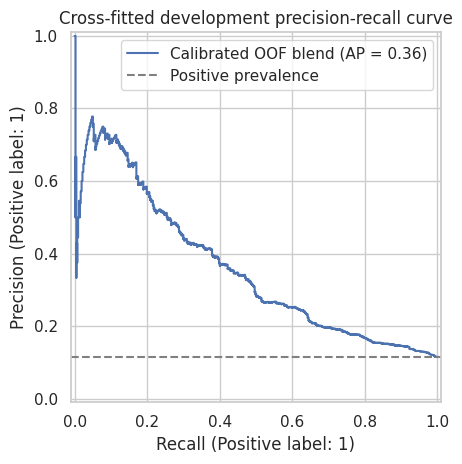


The selected probability strategy is **Calibrated OOF blend**. Its cross-fitted development PR-AUC is **0.3571** and Brier score is **0.0884**, compared with **0.1020** for the prevalence baseline. The operating threshold **0.1776** is chosen from these cross-fitted probabilities, not held-out labels.


In [35]:
# Code Cell 35: Build an OOF blend, calibrate probabilities, and select the threshold.

# Use identical folds for every base model so row-level probabilities are directly comparable.
threshold_folds = list(threshold_cv.split(X_development_raw, y_development))
oof_base_probabilities = {}

for model_name in oof_model_names:
    model_oof = np.full(len(X_development_raw), np.nan, dtype=float)  # One score per development row.
    for fold_train_index, fold_valid_index in threshold_folds:
        fold_model = fresh_candidate_pipeline(model_name)
        fold_model = fit_candidate_pipeline(
            fold_model,
            model_name,
            X_development_raw.iloc[fold_train_index],
            y_development.iloc[fold_train_index],
        )
        model_oof[fold_valid_index] = fold_model.predict_proba(
            X_development_raw.iloc[fold_valid_index]
        )[:, 1]

    if np.isnan(model_oof).any():
        raise RuntimeError(f"Incomplete OOF probabilities for {model_name}.")
    oof_base_probabilities[model_name] = model_oof

oof_probability_frame = pd.DataFrame(oof_base_probabilities)

# A second inner OOF level trains each fold's calibration layer without its validation labels.
calibrated_single_oof = np.full(len(y_development), np.nan, dtype=float)
calibrated_blend_oof = np.full(len(y_development), np.nan, dtype=float)

for outer_fold_number, (outer_train_index, outer_valid_index) in enumerate(threshold_folds):
    outer_train_X = X_development_raw.iloc[outer_train_index]
    outer_train_y = y_development.iloc[outer_train_index]
    inner_cv = StratifiedKFold(
        n_splits=4,  # Inner OOF rows train the fold-specific calibration layer.
        shuffle=True,
        random_state=RANDOM_STATE + 20 + outer_fold_number,
    )
    inner_folds = list(inner_cv.split(outer_train_X, outer_train_y))
    inner_base_probabilities = {}

    for model_name in oof_model_names:
        inner_model_oof = np.full(len(outer_train_X), np.nan, dtype=float)
        for inner_train_index, inner_valid_index in inner_folds:
            inner_model = fresh_candidate_pipeline(model_name)
            inner_model = fit_candidate_pipeline(
                inner_model,
                model_name,
                outer_train_X.iloc[inner_train_index],
                outer_train_y.iloc[inner_train_index],
            )
            inner_model_oof[inner_valid_index] = inner_model.predict_proba(
                outer_train_X.iloc[inner_valid_index]
            )[:, 1]

        if np.isnan(inner_model_oof).any():
            raise RuntimeError(f"Incomplete inner OOF probabilities for {model_name}.")
        inner_base_probabilities[model_name] = inner_model_oof

    inner_probability_frame = pd.DataFrame(inner_base_probabilities)
    inner_single_matrix = probability_to_logit(
        inner_probability_frame[selected_name].to_numpy()
    ).reshape(-1, 1)
    inner_blend_matrix = np.column_stack([
        probability_to_logit(inner_probability_frame[name].to_numpy())
        for name in blend_model_names
    ])

    fold_single_calibrator = LogisticRegression(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    fold_blend_calibrator = LogisticRegression(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    fold_single_calibrator.fit(inner_single_matrix, outer_train_y)
    fold_blend_calibrator.fit(inner_blend_matrix, outer_train_y)

    # Outer validation base scores were produced by models that excluded this entire fold.
    outer_single_matrix = probability_to_logit(
        oof_probability_frame.loc[outer_valid_index, selected_name].to_numpy()
    ).reshape(-1, 1)
    outer_blend_matrix = np.column_stack([
        probability_to_logit(oof_probability_frame.loc[outer_valid_index, name].to_numpy())
        for name in blend_model_names
    ])
    calibrated_single_oof[outer_valid_index] = fold_single_calibrator.predict_proba(
        outer_single_matrix
    )[:, 1]
    calibrated_blend_oof[outer_valid_index] = fold_blend_calibrator.predict_proba(
        outer_blend_matrix
    )[:, 1]

if np.isnan(calibrated_single_oof).any() or np.isnan(calibrated_blend_oof).any():
    raise RuntimeError("The two-level calibration pass left incomplete OOF probabilities.")

# Final calibration layers learn from full-development base OOF scores for later held-out scoring.
single_meta_matrix = probability_to_logit(
    oof_probability_frame[selected_name].to_numpy()
).reshape(-1, 1)
blend_meta_matrix = np.column_stack([
    probability_to_logit(oof_probability_frame[name].to_numpy())
    for name in blend_model_names
])
single_calibrator = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=RANDOM_STATE,
).fit(single_meta_matrix, y_development)
blend_calibrator = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=RANDOM_STATE,
).fit(blend_meta_matrix, y_development)

constant_oof_probability = np.full(len(y_development), y_development.mean(), dtype=float)
calibration_rows = [{
    "Probability strategy": "Constant prevalence baseline",
    "OOF PR-AUC": average_precision_score(y_development, constant_oof_probability),
    "OOF Brier score": brier_score_loss(y_development, constant_oof_probability),
}]

for model_name in oof_model_names:
    model_probability = oof_probability_frame[model_name].to_numpy()
    calibration_rows.append({
        "Probability strategy": f"Raw {model_name}",
        "OOF PR-AUC": average_precision_score(y_development, model_probability),
        "OOF Brier score": brier_score_loss(y_development, model_probability),
    })

calibration_rows.extend([
    {
        "Probability strategy": "Calibrated best single",
        "OOF PR-AUC": average_precision_score(y_development, calibrated_single_oof),
        "OOF Brier score": brier_score_loss(y_development, calibrated_single_oof),
    },
    {
        "Probability strategy": "Calibrated OOF blend",
        "OOF PR-AUC": average_precision_score(y_development, calibrated_blend_oof),
        "OOF Brier score": brier_score_loss(y_development, calibrated_blend_oof),
    },
])
calibration_results = pd.DataFrame(calibration_rows)
display(calibration_results.round(4))

# Keep strategies within a small PR-AUC tolerance, then prefer the better calibrated one.
calibrated_candidates = calibration_results[
    calibration_results["Probability strategy"].isin([
        "Calibrated best single",
        "Calibrated OOF blend",
    ])
].copy()
best_calibrated_pr_auc = calibrated_candidates["OOF PR-AUC"].max()
pr_auc_tolerance = 0.005  # Prevents a tiny ranking gain from accepting much worse calibration.
eligible_strategies = calibrated_candidates[
    calibrated_candidates["OOF PR-AUC"] >= best_calibrated_pr_auc - pr_auc_tolerance
]
chosen_strategy = eligible_strategies.sort_values(
    ["OOF Brier score", "OOF PR-AUC"],
    ascending=[True, False],
).iloc[0]

strategy_key = (
    "blend" if chosen_strategy["Probability strategy"] == "Calibrated OOF blend" else "single"
)
final_strategy_name = chosen_strategy["Probability strategy"]
final_calibrator = blend_calibrator if strategy_key == "blend" else single_calibrator
final_meta_model_names = blend_model_names if strategy_key == "blend" else [selected_name]
final_oof_probability = calibrated_blend_oof if strategy_key == "blend" else calibrated_single_oof

# Select the classification cutoff only after the final OOF probability strategy is frozen.
precision_values, recall_values, thresholds = precision_recall_curve(
    y_development,
    final_oof_probability,
)
f1_values = (
    2 * precision_values[:-1] * recall_values[:-1]
    / np.maximum(precision_values[:-1] + recall_values[:-1], 1e-12)
)
best_index = int(np.argmax(f1_values))
selected_threshold = float(thresholds[best_index])

threshold_rows = []
for threshold_value in sorted({0.10, 0.20, selected_threshold, 0.50}):
    prediction = (final_oof_probability >= threshold_value).astype(int)
    threshold_rows.append({
        "threshold": threshold_value,
        "precision": precision_score(y_development, prediction, zero_division=0),
        "recall": recall_score(y_development, prediction, zero_division=0),
        "f1": f1_score(y_development, prediction, zero_division=0),
        "selected": np.isclose(threshold_value, selected_threshold, atol=1e-8),
    })

display(pd.DataFrame(threshold_rows).round(4))
print("Chosen probability strategy:", final_strategy_name)
print("Frozen OOF threshold:", round(selected_threshold, 4))

PrecisionRecallDisplay.from_predictions(
    y_development,
    final_oof_probability,
    name=final_strategy_name,
)
plt.axhline(y_development.mean(), color="grey", linestyle="--", label="Positive prevalence")
plt.title("Cross-fitted development precision-recall curve")
plt.legend()
plt.tight_layout()
plt.show()

constant_brier = calibration_results.loc[
    calibration_results["Probability strategy"].eq("Constant prevalence baseline"),
    "OOF Brier score",
].iloc[0]
display(Markdown(f'''
The selected probability strategy is **{final_strategy_name}**. Its cross-fitted development PR-AUC is **{chosen_strategy['OOF PR-AUC']:.4f}** and Brier score is **{chosen_strategy['OOF Brier score']:.4f}**, compared with **{constant_brier:.4f}** for the prevalence baseline. The operating threshold **{selected_threshold:.4f}** is chosen from these cross-fitted probabilities, not held-out labels.
'''))


The raw class-weighted models rank customers reasonably well but their probabilities are poorly calibrated: their OOF Brier scores range from **0.1148** to **0.1973**, compared with **0.1020** for the constant-prevalence baseline. Calibration reduces Brier score to **0.0888** for the best single model and **0.0884** for the blend. The blend also has slightly higher OOF PR-AUC, **0.3571** versus **0.3560**, so it becomes the final probability strategy. Its threshold **0.1776** gives development precision **0.3415**, recall **0.4700** and F1 **0.3956**.


### Contact-History Robustness Check


,Feature version,Mean PR-AUC,Standard deviation
0,All pre-call features,0.3519,0.0439
3,Without contact channel,0.3490,0.0494
4,Without age,0.3455,0.0389
1,Without poutcome,0.2934,0.0397
2,Without previous-contact history,0.2541,0.0512


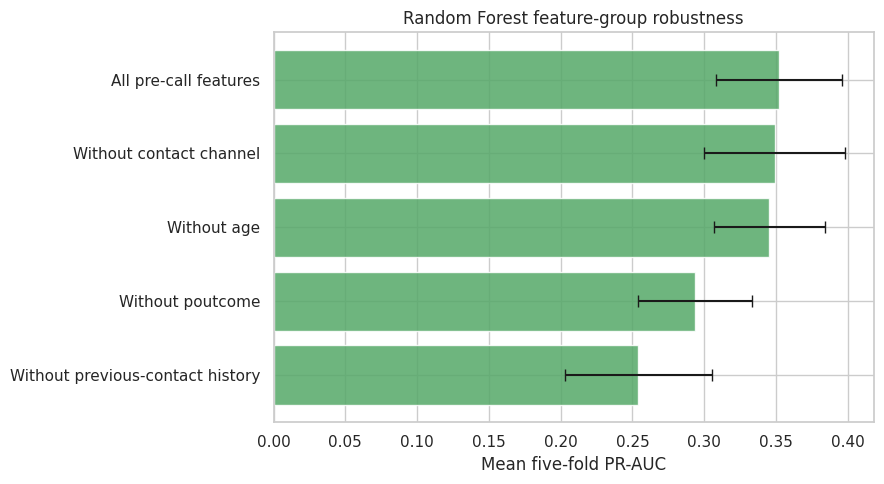

The robustness anchor is **Random Forest** with all-feature PR-AUC **0.3519**.

- **Without contact channel**: PR-AUC **0.3490** (-0.8% versus all features)
- **Without age**: PR-AUC **0.3455** (-1.8% versus all features)
- **Without poutcome**: PR-AUC **0.2934** (-16.6% versus all features)
- **Without previous-contact history**: PR-AUC **0.2541** (-27.8% versus all features)

These changes measure dependence, not causation. The calibrated probability layer is assessed separately through OOF Brier score and subgroup errors.

In [36]:
# Code Cell 36: Test best-single-model robustness across predefined feature removals.

# Rebuild the winning single algorithm for each raw feature subset with unchanged tuned settings.
def rebuild_selected_pipeline(raw_columns):
    engineered_subset = prepare_features(X_development_raw[raw_columns].head(50))  # Rebuilds schema after removal.
    subset_numeric = engineered_subset.select_dtypes(include="number").columns.tolist()  # Fold-scaled fields.
    subset_categorical = engineered_subset.select_dtypes(exclude="number").columns.tolist()  # Encoded fields.

    if selected_name == "CatBoost":
        catboost_parameters = selected_model.named_steps["model"].get_params().copy()
        catboost_parameters.pop("cat_features", None)  # Prevents constructor cloning errors.
        selected_estimator = CatBoostClassifier(**catboost_parameters)
        return Pipeline([
            ("features", clone(feature_builder)),
            ("model", selected_estimator),
        ]), subset_categorical

    selected_estimator = clone(selected_model.named_steps["model"])
    return Pipeline([
        ("features", clone(feature_builder)),
        ("preprocessor", make_preprocessor(subset_numeric, subset_categorical)),
        ("model", selected_estimator),
    ]), subset_categorical


# Feature removals are declared before their results are calculated.
ablation_sets = {
    "All pre-call features": raw_feature_columns,
    "Without poutcome": [column for column in raw_feature_columns if column != "poutcome"],
    "Without previous-contact history": [
        column for column in raw_feature_columns
        if column not in {"poutcome", "pdays", "previous"}
    ],
    "Without contact channel": [column for column in raw_feature_columns if column != "contact"],
    "Without age": [column for column in raw_feature_columns if column != "age"],
}
ablation_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 2,
)
ablation_folds = list(ablation_cv.split(X_development_raw, y_development))
ablation_rows = []  # Stores one comparable summary for each predefined feature version.

for version_name, version_columns in ablation_sets.items():
    version_template, version_categories = rebuild_selected_pipeline(version_columns)
    version_scores = []  # Keeps fold PR-AUC values before mean and spread are calculated.

    for fold_train_index, fold_valid_index in ablation_folds:
        version_model = clone(version_template)  # Starts each fold without learned state.
        fold_fit_arguments = {}
        if selected_name == "CatBoost":
            fold_fit_arguments["model__cat_features"] = version_categories

        version_model.fit(
            X_development_raw.iloc[fold_train_index][version_columns],
            y_development.iloc[fold_train_index],
            **fold_fit_arguments,
        )
        version_probability = version_model.predict_proba(
            X_development_raw.iloc[fold_valid_index][version_columns]
        )[:, 1]
        version_scores.append(
            average_precision_score(y_development.iloc[fold_valid_index], version_probability)
        )

    ablation_rows.append({
        "Feature version": version_name,
        "Mean PR-AUC": np.mean(version_scores),
        "Standard deviation": np.std(version_scores),
    })

ablation_results = pd.DataFrame(ablation_rows).sort_values("Mean PR-AUC", ascending=False)
display(ablation_results.round(4))

plot_table = ablation_results.sort_values("Mean PR-AUC")
plt.figure(figsize=(9, 5))
plt.barh(
    plot_table["Feature version"],
    plot_table["Mean PR-AUC"],
    xerr=plot_table["Standard deviation"],
    color="#55a868",
    alpha=0.85,
    capsize=4,
)
plt.title(f"{selected_name} feature-group robustness")
plt.xlabel("Mean five-fold PR-AUC")
plt.tight_layout()
plt.show()

all_feature_score = ablation_results.loc[
    ablation_results["Feature version"].eq("All pre-call features"), "Mean PR-AUC"
].iloc[0]
ablation_explanation_rows = []
for _, row in ablation_results.iterrows():
    if row["Feature version"] == "All pre-call features":
        continue
    relative_change = (row["Mean PR-AUC"] / all_feature_score - 1) * 100  # Negative means dependence.
    ablation_explanation_rows.append(
        f"- **{row['Feature version']}**: PR-AUC **{row['Mean PR-AUC']:.4f}** ({relative_change:+.1f}% versus all features)"
    )

display(Markdown(
    f"The robustness anchor is **{selected_name}** with all-feature PR-AUC **{all_feature_score:.4f}**.\n\n"
    + "\n".join(ablation_explanation_rows)
    + "\n\nThese changes measure dependence, not causation. The calibrated probability layer is assessed separately through OOF Brier score and subgroup errors."
))


Removing contact channel changes Random Forest PR-AUC by only **-0.8%**, while removing age changes it by **-1.8%**. The larger drops come from removing `poutcome` (**-16.6%**) and all previous-contact history (**-27.8%**). This shows that the model is not strongly dependent on age or contact channel alone, but it relies heavily on earlier campaign information and may be weaker for customers with little history.


### Final Held-Out Evaluation


In [37]:
# Code Cell 37: Evaluate the frozen calibrated strategy on the held-out split.

def probability_frame_from_models(model_dictionary, raw_frame, model_names):
    # Preserve model order because the calibration layer expects the same input columns used in training.
    return pd.DataFrame({
        name: model_dictionary[name].predict_proba(raw_frame)[:, 1]
        for name in model_names
    }, index=raw_frame.index)


def calibrated_probability_from_frame(probability_frame):
    meta_matrix = np.column_stack([
        probability_to_logit(probability_frame[name].to_numpy())
        for name in final_meta_model_names
    ])
    return final_calibrator.predict_proba(meta_matrix)[:, 1]


def predict_final_probability(raw_frame):
    base_frame = probability_frame_from_models(candidate_models, raw_frame, final_meta_model_names)
    return calibrated_probability_from_frame(base_frame)


# The calibration strategy and threshold are already fixed before these labels are scored.
test_probability = predict_final_probability(X_test_raw)  # Uses frozen base models and calibration layer.
test_prediction = (test_probability >= selected_threshold).astype(int)  # Applies the OOF-selected cutoff.
final_test_metrics = classification_metrics(
    y_test,
    test_probability,
    threshold=selected_threshold,
)
test_constant_probability = np.full(len(y_test), y_development.mean(), dtype=float)  # No-skill calibration.
test_brier_baseline = brier_score_loss(y_test, test_constant_probability)  # Lower is better.
final_test_metrics["Brier score"] = brier_score_loss(y_test, test_probability)
final_test_metrics["Brier baseline"] = test_brier_baseline
final_test_metrics["Brier skill score"] = 1 - final_test_metrics["Brier score"] / test_brier_baseline

# Bootstrap the held-out rows to show uncertainty from only 104 positive examples.
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_pr_auc = []  # Captures ranking uncertainty across resampled customers.
bootstrap_recall = []  # Captures threshold-performance uncertainty.
test_labels = y_test.to_numpy()

for _ in range(1000):
    sample_index = rng.integers(0, len(y_test), len(y_test))
    sampled_labels = test_labels[sample_index]
    if np.unique(sampled_labels).size < 2:
        continue  # PR-AUC is undefined when a bootstrap sample contains one class.
    bootstrap_pr_auc.append(
        average_precision_score(sampled_labels, test_probability[sample_index])
    )
    bootstrap_recall.append(
        recall_score(sampled_labels, test_prediction[sample_index], zero_division=0)
    )

confidence_intervals = pd.DataFrame({
    "metric": ["PR-AUC", "Recall"],
    "lower_95": [
        np.quantile(bootstrap_pr_auc, 0.025),
        np.quantile(bootstrap_recall, 0.025),
    ],
    "upper_95": [
        np.quantile(bootstrap_pr_auc, 0.975),
        np.quantile(bootstrap_recall, 0.975),
    ],
})

# Lift converts model ranking into fixed contact-budget evidence.
ranking = pd.DataFrame({"actual": test_labels, "probability": test_probability}).sort_values(
    "probability",
    ascending=False,
)
lift_rows = []
for contact_share in [0.10, 0.20, 0.30]:
    customer_count = int(np.ceil(len(ranking) * contact_share))
    contacted = ranking.head(customer_count)
    lift_rows.append({
        "contact_share": contact_share,
        "customers_contacted": customer_count,
        "subscription_rate": contacted["actual"].mean(),
        "lift_over_random": contacted["actual"].mean() / ranking["actual"].mean(),
        "subscriber_capture_rate": contacted["actual"].sum() / ranking["actual"].sum(),
    })

display(pd.Series(final_test_metrics, name="Final held-out evaluation").to_frame())
display(confidence_intervals.round(4))
display(pd.DataFrame(lift_rows).round(4))
print("Final probability strategy:", final_strategy_name)
print("Frozen OOF threshold:", round(selected_threshold, 4))
print("\nClassification report:\n")
print(classification_report(y_test, test_prediction, target_names=["No", "Yes"], digits=4))

top_ten_result = pd.DataFrame(lift_rows).iloc[0]
display(Markdown(f'''
The held-out PR-AUC is **{final_test_metrics['PR-AUC']:.4f}** with 95% bootstrap interval **{confidence_intervals.loc[0, 'lower_95']:.4f}-{confidence_intervals.loc[0, 'upper_95']:.4f}**. At threshold **{selected_threshold:.4f}**, precision is **{final_test_metrics['Precision']:.4f}**, recall **{final_test_metrics['Recall']:.4f}**, and F1 **{final_test_metrics['F1']:.4f}**. The Brier score is **{final_test_metrics['Brier score']:.4f}** versus baseline **{test_brier_baseline:.4f}**, giving Brier skill **{final_test_metrics['Brier skill score']:.3f}**. The highest-scored 10% captures **{top_ten_result['subscriber_capture_rate']:.2%}** of subscribers with lift **{top_ten_result['lift_over_random']:.2f}**.
'''))


,Final held-out evaluation
PR-AUC,0.387440
ROC-AUC,0.757647
Precision,0.387324
Recall,0.528846
F1,0.447154
Balanced accuracy,0.710116
Brier score,0.087436
Brier baseline,0.101711
Brier skill score,0.140355


,metric,lower_95,upper_95
0,PR-AUC,0.3010,0.4918
1,Recall,0.4348,0.6279


,contact_share,customers_contacted,subscription_rate,lift_over_random,subscriber_capture_rate
0,0.1,91,0.4286,3.7294,0.3750
1,0.2,181,0.3425,2.9808,0.5962
2,0.3,272,0.2537,2.2075,0.6635


Final probability strategy: Calibrated OOF blend
Frozen OOF threshold: 0.1776

Classification report:

              precision    recall  f1-score   support

          No     0.9358    0.8914    0.9130       801
         Yes     0.3873    0.5288    0.4472       104

    accuracy                         0.8497       905
   macro avg     0.6616    0.7101    0.6801       905
weighted avg     0.8728    0.8497    0.8595       905




The held-out PR-AUC is **0.3874** with 95% bootstrap interval **0.3010-0.4918**. At threshold **0.1776**, precision is **0.3873**, recall **0.5288**, and F1 **0.4472**. The Brier score is **0.0874** versus baseline **0.1017**, giving Brier skill **0.140**. The highest-scored 10% captures **37.50%** of subscribers with lift **3.73**.


The calibrated blend records held-out PR-AUC **0.3874** and ROC-AUC **0.7576**. At threshold **0.1776**, it identifies **55 of 104** subscribers and misses **49**; it also produces **87** false-positive calls. Precision is **0.3873**, recall **0.5288**, F1 **0.4472** and balanced accuracy **0.7101**. Its Brier score improves to **0.0874** against baseline **0.1017**, giving positive Brier skill of **0.140**. Accuracy is not the selection metric because the lower threshold deliberately accepts more calls to detect more subscribers.


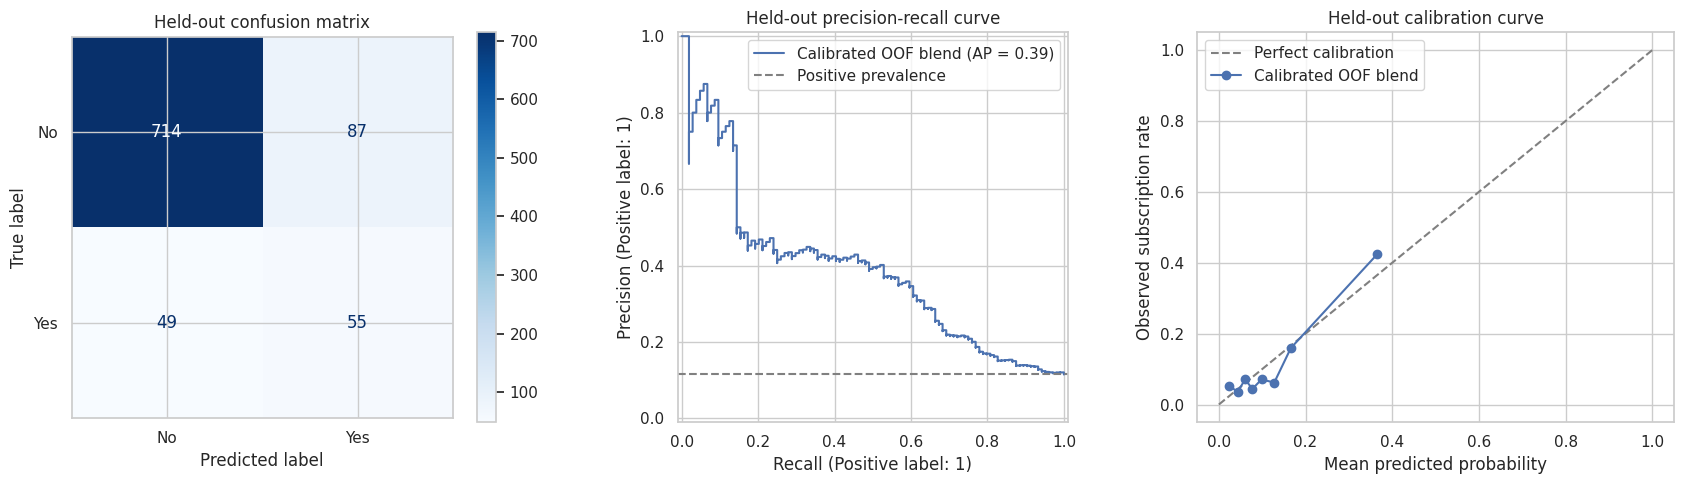

In [38]:
# Code Cell 38: Plot held-out errors, ranking quality, and calibration.

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["No", "Yes"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Held-out confusion matrix")  # Shows missed subscribers and unnecessary calls.

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probability,
    name=final_strategy_name,
    ax=axes[1],
)
axes[1].axhline(y_test.mean(), color="grey", linestyle="--", label="Positive prevalence")
axes[1].set_title("Held-out precision-recall curve")  # Evaluates ranking across every threshold.
axes[1].legend()

observed_rate, mean_probability = calibration_curve(
    y_test,
    test_probability,
    n_bins=8,  # Quantile bins keep a similar number of customers in each point.
    strategy="quantile",
)
axes[2].plot([0, 1], [0, 1], color="grey", linestyle="--", label="Perfect calibration")
axes[2].plot(mean_probability, observed_rate, marker="o", label=final_strategy_name)
axes[2].set_title("Held-out calibration curve")
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Observed subscription rate")
axes[2].legend()

plt.tight_layout()
plt.show()


The confusion matrix shows the expected recall–precision trade-off: more subscribers are found, but more non-subscribers are contacted. The precision-recall curve remains well above the **11.49%** positive prevalence over the useful ranking region. The calibration result is also supported numerically because Brier score is lower than the prevalence baseline, although the curve should still be monitored with new campaign data.


### Subgroup Error Review


In [39]:
# Code Cell 39: Review held-out errors across predefined customer groups.

# These diagnostic groups are fixed before their output is interpreted.
error_audit = test_df[["contact", "poutcome", "age"]].copy()
error_audit["age_band"] = pd.cut(
    error_audit["age"],
    bins=[17, 29, 39, 49, 59, np.inf],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"],
)
error_audit["actual"] = test_labels  # Keeps the original held-out outcome beside each segment.
error_audit["predicted"] = test_prediction  # Uses the one frozen global threshold.

subgroup_rows = []  # Produces one row per field-category combination.
for field in ["contact", "poutcome", "age_band"]:
    for group_name, group in error_audit.groupby(field, observed=False):
        true_positive = ((group["actual"] == 1) & (group["predicted"] == 1)).sum()  # Correct calls.
        actual_positive = (group["actual"] == 1).sum()  # Recall denominator.
        predicted_positive = (group["predicted"] == 1).sum()  # Precision denominator.
        subgroup_rows.append({
            "field": field,
            "group": str(group_name),
            "rows": len(group),
            "actual_positive_rate": group["actual"].mean(),
            "predicted_positive_rate": group["predicted"].mean(),
            "recall": true_positive / actual_positive if actual_positive else np.nan,
            "precision": true_positive / predicted_positive if predicted_positive else np.nan,
        })

subgroup_results = pd.DataFrame(subgroup_rows)
display(subgroup_results.round(4))
print("Groups with fewer than 25 rows:", int((subgroup_results["rows"] < 25).sum()))

unknown_contact_row = subgroup_results[
    subgroup_results["field"].eq("contact") & subgroup_results["group"].eq("unknown")
].iloc[0]
older_row = subgroup_results[
    subgroup_results["field"].eq("age_band") & subgroup_results["group"].eq("60+")
].iloc[0]
display(Markdown(f'''
For `contact=unknown`, the model has recall **{unknown_contact_row['recall']:.4f}** across **{int(unknown_contact_row['rows'])}** customers. In the 60+ band, actual positive rate is **{older_row['actual_positive_rate']:.2%}**, predicted-positive rate **{older_row['predicted_positive_rate']:.2%}**, recall **{older_row['recall']:.4f}**, and precision **{older_row['precision']:.4f}**. These are monitoring and fairness warnings, not reasons for separate group-specific thresholds from this small sample.
'''))


,field,group,rows,actual_positive_rate,predicted_positive_rate,recall,precision
0,contact,cellular,575,0.1409,0.2174,0.6049,0.3920
1,contact,telephone,67,0.1194,0.2388,0.7500,0.3750
2,contact,unknown,263,0.0570,0.0038,0.0000,0.0000
3,poutcome,failure,106,0.1509,0.2736,0.6250,0.3448
4,poutcome,other,42,0.1905,0.3095,0.6250,0.3846
5,poutcome,success,24,0.6250,1.0000,1.0000,0.6250
6,poutcome,unknown,733,0.0887,0.1037,0.3846,0.3289
7,age_band,18-29,88,0.1477,0.2500,0.6923,0.4091
8,age_band,30-39,349,0.0888,0.1203,0.4516,0.3333
9,age_band,40-49,256,0.1172,0.0898,0.4333,0.5652


Groups with fewer than 25 rows: 1



For `contact=unknown`, the model has recall **0.0000** across **263** customers. In the 60+ band, actual positive rate is **23.81%**, predicted-positive rate **83.33%**, recall **1.0000**, and precision **0.2857**. These are monitoring and fairness warnings, not reasons for separate group-specific thresholds from this small sample.


The subgroup output exposes two important weaknesses. For the **263** customers with `contact=unknown`, the model detects none of the **15** actual subscribers, giving recall **0.0000**. In the 60+ group, it detects all **10** subscribers but marks **35 of 42** customers positive, leaving precision at **0.2857**. These small and uneven groups need data-quality and fairness monitoring; the notebook correctly avoids creating separate thresholds from this limited evidence.


### Model Interpretation


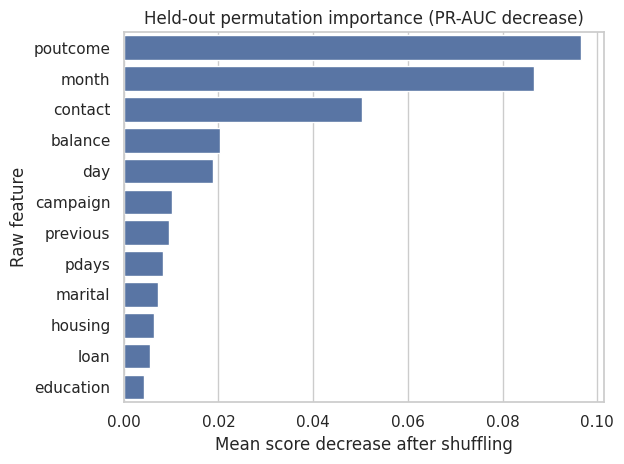

,feature,importance_mean,importance_std
14,poutcome,0.0966,0.0267
10,month,0.0866,0.0142
8,contact,0.0504,0.0083
5,balance,0.0204,0.0080
9,day,0.0188,0.0061
11,campaign,0.0102,0.0077
13,previous,0.0096,0.0054
12,pdays,0.0083,0.0071
2,marital,0.0073,0.0031
6,housing,0.0065,0.0034



The strongest held-out reliance is **poutcome**, with mean PR-AUC decrease **0.0966** after shuffling. Importance measures reliance rather than causation, and correlated fields can divide or hide each other's contribution.


In [40]:
# Code Cell 40: Calculate held-out permutation importance for the final strategy.

# Manual permutation supports the calibrated blend, which is stored as several fitted components.
baseline_importance_score = average_precision_score(y_test, test_probability)  # Unshuffled reference.
importance_rng = np.random.default_rng(RANDOM_STATE)  # Makes all ten shuffles reproducible.
importance_rows = []  # Holds raw-feature mean and variation.

for feature_name in X_test_raw.columns:  # Tests the complete raw input contract one field at a time.
    score_decreases = []  # Repeated shuffles reduce dependence on one permutation.
    for _ in range(10):
        permuted_frame = X_test_raw.copy()
        permuted_frame[feature_name] = importance_rng.permutation(
            permuted_frame[feature_name].to_numpy()
        )
        permuted_probability = predict_final_probability(permuted_frame)  # Runs the full calibrated strategy.
        score_decreases.append(
            baseline_importance_score - average_precision_score(y_test, permuted_probability)
        )

    importance_rows.append({
        "feature": feature_name,
        "importance_mean": np.mean(score_decreases),
        "importance_std": np.std(score_decreases),
    })

importance_table = (
    pd.DataFrame(importance_rows)
    .sort_values("importance_mean", ascending=False)
    .head(12)
)

sns.barplot(data=importance_table, y="feature", x="importance_mean", color="#4c72b0")
plt.title("Held-out permutation importance (PR-AUC decrease)")
plt.xlabel("Mean score decrease after shuffling")
plt.ylabel("Raw feature")
plt.tight_layout()
plt.show()
display(importance_table.round(4))

top_importance = importance_table.iloc[0]
display(Markdown(f'''
The strongest held-out reliance is **{top_importance['feature']}**, with mean PR-AUC decrease **{top_importance['importance_mean']:.4f}** after shuffling. Importance measures reliance rather than causation, and correlated fields can divide or hide each other's contribution.
'''))


`poutcome` is the strongest held-out feature, reducing PR-AUC by **0.0966** when shuffled. Month follows at **0.0866**, then contact type at **0.0504** and balance at **0.0204**. The result agrees with the history ablation, while the small contact-channel ablation drop suggests that correlated fields can recover some information when contact itself is removed. These values describe model reliance, not causal effect.


## 8. Model Save and Reload


In [41]:
# Code Cell 41: Save and reload the complete calibrated scoring artifact.

artifact_dir = PROJECT_PATH / "model_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / "bank_subscription_pipeline.joblib"  # One portable submission artifact path.

# Store only the base models required by the chosen calibration strategy.
artifact_base_models = {  # Excludes candidate models that the chosen strategy does not need.
    name: candidate_models[name]
    for name in final_meta_model_names
}
artifact = {
    "base_models": artifact_base_models,
    "calibrator": final_calibrator,
    "strategy_key": strategy_key,
    "strategy_name": final_strategy_name,
    "meta_model_names": final_meta_model_names,
    "threshold": selected_threshold,
    "best_single_model": selected_name,
    "prediction_point": "before the current campaign call begins",
    "raw_feature_columns": raw_feature_columns,
    "excluded_features": ["duration"],
    "scikit_learn_version": sklearn.__version__,
    "catboost_version": catboost.__version__,
}
joblib.dump(artifact, artifact_path)  # Writes models, calibration layer, threshold and metadata together.


def predict_with_artifact(loaded_artifact, raw_frame):
    loaded_names = loaded_artifact["meta_model_names"]  # Preserves calibration-column order.
    loaded_probability_frame = probability_frame_from_models(
        loaded_artifact["base_models"],
        raw_frame,
        loaded_names,
    )
    loaded_meta_matrix = np.column_stack([
        probability_to_logit(loaded_probability_frame[name].to_numpy())
        for name in loaded_names
    ])
    return loaded_artifact["calibrator"].predict_proba(loaded_meta_matrix)[:, 1]


# Reload from disk instead of reusing the in-memory dictionary.
reloaded_artifact = joblib.load(artifact_path)
reloaded_probability = predict_with_artifact(reloaded_artifact, X_test_raw.head(25))
reload_check = np.allclose(reloaded_probability, test_probability[:25])

print("Saved artifact:", artifact_path.name)
print("Stored strategy:", reloaded_artifact["strategy_name"])
print("Stored base models:", reloaded_artifact["meta_model_names"])
print("Reloaded raw-row predictions match:", reload_check)
if not reload_check:
    raise AssertionError("Reloaded calibrated predictions do not match.")

display(Markdown(f'''
The saved artifact contains **{reloaded_artifact['strategy_name']}**, its ordered base models, calibration layer and threshold. The same-session disk reload reproduces the first 25 held-out probabilities: **{reload_check}**. A separate cold-runtime load remains the stronger portability test.
'''))


Saved artifact: bank_subscription_pipeline.joblib
Stored strategy: Calibrated OOF blend
Stored base models: ['Logistic Regression', 'Random Forest', 'CatBoost']
Reloaded raw-row predictions match: True



The saved artifact contains **Calibrated OOF blend**, its ordered base models, calibration layer and threshold. The same-session disk reload reproduces the first 25 held-out probabilities: **True**. A separate cold-runtime load remains the stronger portability test.


The saved artifact contains the fitted Logistic Regression, Random Forest and CatBoost pipelines in the required order, followed by the calibration layer and threshold. Reloading the file reproduces the first 25 probabilities exactly, so the same-session save and reload check passes. A separate cold-runtime load remains the final engineering check before claiming production portability, but it does not block this Colab submission.


## Conclusion


In [42]:
# Code Cell 42: Write a conclusion linked directly to executed results.

# Pull every number from live objects so model names and metrics cannot drift apart.
selected_cv_row = cv_summary.loc[cv_summary["Model"].eq(selected_name)].iloc[0]  # Best single evidence.
runner_up_cv_row = cv_summary.iloc[1]  # Keeps the near-tie visible in the conclusion.
chosen_calibration_row = calibration_results.loc[
    calibration_results["Probability strategy"].eq(final_strategy_name)
].iloc[0]
history_ablation_row = ablation_results.loc[
    ablation_results["Feature version"].eq("Without previous-contact history")
].iloc[0]
all_feature_ablation_row = ablation_results.loc[
    ablation_results["Feature version"].eq("All pre-call features")
].iloc[0]
history_relative_change = (  # Quantifies dependence on previous campaign information.
    history_ablation_row["Mean PR-AUC"] / all_feature_ablation_row["Mean PR-AUC"] - 1
) * 100

display(Markdown(f'''
The strongest single model is **{selected_name}** with repeated-CV PR-AUC **{selected_cv_row['Mean CV PR-AUC']:.4f} ± {selected_cv_row['CV standard deviation']:.4f}**. **{runner_up_cv_row['Model']}** is close at **{runner_up_cv_row['Mean CV PR-AUC']:.4f}**, so the ranking should be treated as a narrow development-set result rather than proof of a large model difference.

The final probability strategy is **{final_strategy_name}**. Cross-fitted development PR-AUC is **{chosen_calibration_row['OOF PR-AUC']:.4f}** and Brier score **{chosen_calibration_row['OOF Brier score']:.4f}**. On the held-out split it records PR-AUC **{final_test_metrics['PR-AUC']:.4f}**, ROC-AUC **{final_test_metrics['ROC-AUC']:.4f}**, precision **{final_test_metrics['Precision']:.4f}**, recall **{final_test_metrics['Recall']:.4f}**, F1 **{final_test_metrics['F1']:.4f}**, and Brier score **{final_test_metrics['Brier score']:.4f}** versus baseline **{test_brier_baseline:.4f}**.

Contacting the highest-scored 10% gives lift **{top_ten_result['lift_over_random']:.2f}** and captures **{top_ten_result['subscriber_capture_rate']:.2%}** of held-out subscribers. Removing previous-contact history changes the best-single-model PR-AUC by **{history_relative_change:+.1f}%**, showing how strongly performance depends on campaign history. The subgroup table and calibration curve must remain part of monitoring because aggregate performance can hide weak customer segments.

This is a prioritization model, not an automatic acceptance, rejection or guaranteed-sales system. Call duration is excluded, learned transformations stay inside development folds, calibration is cross-fitted, and the held-out split is not used to select the model, blend weights or threshold. Nested cross-validation or genuinely new campaign data would provide stronger future validation.
'''))



The strongest single model is **Random Forest** with repeated-CV PR-AUC **0.3720 ± 0.0413**. **CatBoost** is close at **0.3695**, so the ranking should be treated as a narrow development-set result rather than proof of a large model difference.

The final probability strategy is **Calibrated OOF blend**. Cross-fitted development PR-AUC is **0.3571** and Brier score **0.0884**. On the held-out split it records PR-AUC **0.3874**, ROC-AUC **0.7576**, precision **0.3873**, recall **0.5288**, F1 **0.4472**, and Brier score **0.0874** versus baseline **0.1017**.

Contacting the highest-scored 10% gives lift **3.73** and captures **37.50%** of held-out subscribers. Removing previous-contact history changes the best-single-model PR-AUC by **-27.8%**, showing how strongly performance depends on campaign history. The subgroup table and calibration curve must remain part of monitoring because aggregate performance can hide weak customer segments.

This is a prioritization model, not an automatic acceptance, rejection or guaranteed-sales system. Call duration is excluded, learned transformations stay inside development folds, calibration is cross-fitted, and the held-out split is not used to select the model, blend weights or threshold. Nested cross-validation or genuinely new campaign data would provide stronger future validation.


### Practical Takeaways

- The final score can help the bank decide which customers to contact first, but it should not be treated as a guaranteed subscription decision.
- Previous campaign history contributes much more than age or contact channel alone, so predictions for customers with little history need extra care.
- Customers with `contact=unknown` are still a weak group for the model. Better contact data would be more useful than forcing a separate threshold for this small segment.
- The threshold **0.1776** balances precision and recall for this notebook. A real campaign should replace it with a threshold based on call cost, deposit value and available staff.
- New campaign data should be used to check whether calibration, lift and subgroup performance remain stable over time.


### Final Summary

In this notebook, I first understood the banking data through quality checks, charts and hypothesis tests. The main challenge was the small subscriber class, so I focused on PR-AUC, recall, precision and lift instead of depending on accuracy. I also removed call duration from modeling because it would not be available when the bank is deciding whom to call.

I compared four learned models with a dummy baseline. Random Forest gave the best individual cross-validation result, but CatBoost was very close. Instead of assuming that one model was clearly superior, I tested a calibrated blend of Logistic Regression, Random Forest and CatBoost using out-of-fold predictions. This improved the reliability of the probabilities and was selected without using the held-out labels.

The final held-out result shows that the model has useful ranking ability, but it is not perfect. It finds just over half of the subscribers at the selected threshold, gives strong lift in the top 10%, and produces better-calibrated probabilities than the prevalence baseline. At the same time, it still struggles when contact information is unknown and depends heavily on previous campaign history.

Overall, I would use this work as a customer-prioritization prototype. It gives the bank a more focused calling list, while the uncertainty, subgroup checks and limitations make it clear where human judgment and better future data are still needed.
